# COMPONENTE PRÁCTICO EXPERIMENTAL - MINERÍA DE DATOS

## Predicción del abandono de clientes en una empresa de telecomunicaciones mediante técnicas de minería de datos

**Asignatura:** Minería de Datos  
**Universidad:** Universidad Estatal Amazónica  
**Dataset:** Telco Customer Churn  
**Estudiantes:** Jorge Ramírez y Denisis Portilla  

### Objetivo general
Aplicar técnicas de minería de datos para desarrollar un modelo predictivo que permita identificar clientes con riesgo de abandonar los servicios de una empresa de telecomunicaciones.

In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
print(uploaded.keys())

dict_keys(['WA_Fn-UseC_-Telco-Customer-Churn.csv'])


In [4]:
import pandas as pd

nombre_archivo = list(uploaded.keys())[0]

df = pd.read_csv(nombre_archivo)

print("Dataset cargado correctamente.")
print("Archivo:", nombre_archivo)

Dataset cargado correctamente.
Archivo: WA_Fn-UseC_-Telco-Customer-Churn.csv


## 2. Comprensión inicial del conjunto de datos

En esta etapa se realiza una primera exploración del conjunto de datos con el propósito de conocer su estructura, dimensiones, variables y tipos de datos antes de efectuar cualquier proceso de limpieza o transformación.

### 2.1 Visualización de los primeros registros

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2.2 Dimensiones del conjunto de datos

In [6]:
filas, columnas = df.shape

print("Número de registros:", filas)
print("Número de variables:", columnas)

Número de registros: 7043
Número de variables: 21


**Interpretación:**

El conjunto de datos contiene 7.043 registros correspondientes a clientes y 21 variables relacionadas con sus características demográficas, servicios contratados, facturación y permanencia en la empresa. La cantidad de registros y variables cumple con los requisitos establecidos para el desarrollo del componente práctico-experimental.

In [7]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

### 2.3 Estructura y tipos de datos

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Interpretación:**  
El conjunto de datos está compuesto por 7.043 registros y 21 variables. Se identifican 18 variables de tipo `object`, principalmente correspondientes a características categóricas de los clientes y servicios contratados; dos variables de tipo entero (`SeniorCitizen` y `tenure`) y una variable de tipo decimal (`MonthlyCharges`).

Inicialmente, todas las columnas presentan 7.043 valores no nulos. Sin embargo, se observa una inconsistencia en la variable `TotalCharges`, ya que representa el total monetario acumulado de cada cliente, pero Pandas la reconoce como tipo `object` en lugar de numérico. Esta situación requiere una revisión específica para determinar si existen espacios vacíos, caracteres no numéricos u otros valores que estén impidiendo su correcta interpretación.

### 2.4 Variable objetivo: Churn

In [9]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [10]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


**Interpretación:**

De los 7.043 clientes analizados, 5.174 permanecieron en la empresa, equivalentes aproximadamente al 73,46 %, mientras que 1.869 abandonaron el servicio, correspondientes al 26,54 %. Por lo tanto, la variable objetivo presenta cierto desequilibrio entre las clases, aspecto que deberá considerarse durante la evaluación de los modelos. Debido a ello, no será conveniente evaluar el rendimiento utilizando únicamente la exactitud (Accuracy), sino complementarla posteriormente con métricas como Precision, Recall y F1-Score.

### 2.5 Verificación de valores faltantes

Se verifica la presencia de valores nulos en el conjunto de datos y se analizan posibles valores vacíos almacenados como cadenas de texto, con el propósito de identificar inconsistencias que deban ser tratadas posteriormente durante el preprocesamiento.

In [12]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [13]:
espacios_totalcharges = (df['TotalCharges'].astype(str).str.strip() == '').sum()

print("Valores vacíos en TotalCharges:", espacios_totalcharges)

Valores vacíos en TotalCharges: 11


In [14]:
porcentaje_vacios = (espacios_totalcharges / len(df)) * 100

print("Porcentaje de valores vacíos en TotalCharges:",
      round(porcentaje_vacios, 2), "%")

Porcentaje de valores vacíos en TotalCharges: 0.16 %


**Interpretación:**  
La verificación inicial mediante `isnull()` no identificó valores nulos en ninguna de las 21 variables. No obstante, al revisar específicamente la variable `TotalCharges`, se detectaron 11 registros almacenados como espacios vacíos, lo que representa aproximadamente el 0,16 % del conjunto de datos.

Este hallazgo evidencia que algunos valores faltantes pueden no ser reconocidos directamente como `NaN` debido a la forma en que fueron almacenados. Por esta razón, la variable `TotalCharges` requerirá un tratamiento posterior durante la etapa de preprocesamiento antes de utilizarse en los modelos predictivos.

### 2.6 Verificación de registros duplicados

Se analiza la existencia de registros completamente duplicados en el conjunto de datos con el propósito de evitar que observaciones repetidas puedan introducir sesgos en el análisis y en el entrenamiento de los modelos.

In [15]:
duplicados = df.duplicated().sum()

porcentaje_duplicados = (duplicados / len(df)) * 100

print("Registros duplicados:", duplicados)
print("Porcentaje de duplicados:", round(porcentaje_duplicados, 2), "%")

Registros duplicados: 0
Porcentaje de duplicados: 0.0 %


In [16]:
df['customerID'].duplicated().sum()

np.int64(0)

**Interpretación:**  
No se identificaron registros duplicados en el conjunto de datos, por lo que el porcentaje de duplicados corresponde al 0 %. Asimismo, la variable `customerID` no presenta valores repetidos, lo que confirma que cada registro corresponde a un cliente diferente.

Por lo tanto, no será necesario aplicar procedimientos de eliminación o consolidación de registros duplicados durante la etapa de preprocesamiento.

## 3. Análisis estadístico descriptivo

Se realiza un análisis estadístico de las variables numéricas con el propósito de conocer su distribución, tendencia central y dispersión. Para ello se analizan medidas como cantidad de registros, media, desviación estándar, valores mínimos y máximos, así como los cuartiles 25 %, 50 % y 75 %.

In [17]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Interpretación:**  
Las tres variables numéricas reconocidas inicialmente por Pandas contienen 7.043 registros.

- **SeniorCitizen:** presenta una media de 0,162. Debido a que esta variable es binaria (0 = no es adulto mayor y 1 = sí es adulto mayor), este valor indica que aproximadamente el 16,2 % de los clientes pertenece al grupo de adultos mayores. La mediana y los cuartiles son 0, lo que evidencia que la mayoría de los clientes no pertenece a esta categoría.

- **tenure:** el tiempo promedio de permanencia de los clientes es de aproximadamente 32,37 meses, mientras que la mediana es de 29 meses. El 25 % de los clientes tiene una permanencia de hasta 9 meses y el 75 % hasta 55 meses. El rango observado se encuentra entre 0 y 72 meses, lo que evidencia una amplia variación en la antigüedad de los clientes.

- **MonthlyCharges:** el cargo mensual promedio es de aproximadamente 64,76, mientras que la mediana corresponde a 70,35. El 25 % de los clientes paga hasta 35,50 mensuales y el 75 % hasta 89,85. Los valores se encuentran entre 18,25 y 118,75.

La variable `TotalCharges` no aparece en este análisis estadístico debido a que actualmente está almacenada como tipo `object`. Esta variable será revisada y convertida posteriormente a formato numérico para poder incorporarla correctamente en el análisis.

### 3.1 Revisión estadística de la variable TotalCharges

Debido a que `TotalCharges` fue identificada inicialmente como una variable de tipo `object`, se realiza una conversión temporal a formato numérico con el propósito de analizar sus estadísticas descriptivas sin modificar todavía el conjunto de datos original.

In [18]:
totalcharges_numerico = pd.to_numeric(df['TotalCharges'], errors='coerce')

totalcharges_numerico.describe()

,TotalCharges
count,7032.000000
mean,2283.300441
std,2266.771362
min,18.800000
25%,401.450000
50%,1397.475000
75%,3794.737500
max,8684.800000


In [19]:
print("Valores numéricos:", totalcharges_numerico.notna().sum())
print("Valores convertidos a NaN:", totalcharges_numerico.isna().sum())

Valores numéricos: 7032
Valores convertidos a NaN: 11


**Interpretación:**  
La variable `TotalCharges` contiene 7.032 valores numéricos válidos y 11 registros que, al intentar convertirse a formato numérico, fueron transformados en `NaN`, confirmando que corresponden a valores vacíos previamente almacenados como texto.

El valor promedio de los cargos totales es de aproximadamente 2.283,30, mientras que la mediana es de 1.397,48. La diferencia considerable entre la media y la mediana sugiere que la distribución puede presentar asimetría hacia valores altos.

El 25 % de los clientes presenta cargos totales de hasta 401,45, mientras que el 75 % alcanza aproximadamente 3.794,74. Los valores oscilan entre 18,80 y 8.684,80. Debido a esta amplitud y a la diferencia entre las medidas de tendencia central, será necesario complementar este análisis con visualizaciones y técnicas de detección de valores atípicos.

In [20]:
import matplotlib.pyplot as plt

### 3.2 Visualización de la distribución de variables numéricas

Se utilizan gráficos para analizar la forma de las distribuciones, la dispersión de los datos y posibles valores extremos.

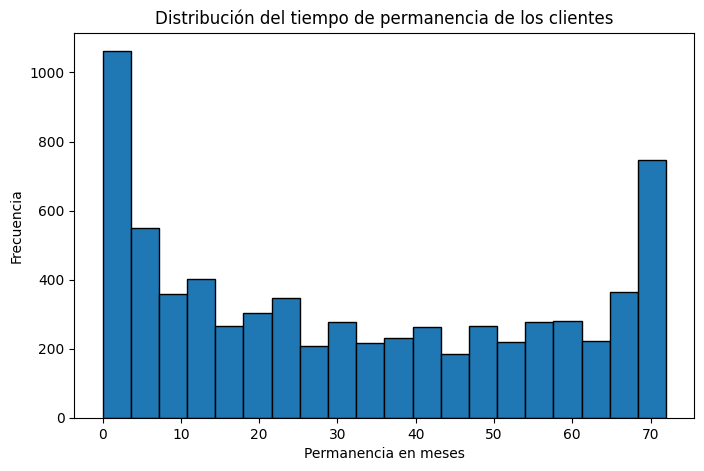

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(df['tenure'], bins=20, edgecolor='black')
plt.title('Distribución del tiempo de permanencia de los clientes')
plt.xlabel('Permanencia en meses')
plt.ylabel('Frecuencia')
plt.show()

**Interpretación:**  
La distribución de `tenure` muestra una alta concentración de clientes con pocos meses de permanencia, especialmente en los primeros meses. También se observa un incremento de clientes en los valores cercanos a 70-72 meses. Esto indica que en el conjunto de datos existen tanto clientes relativamente nuevos como clientes con una larga permanencia en la empresa.

La distribución no es uniforme y presenta concentraciones en los extremos, por lo que resulta conveniente analizar posteriormente si la permanencia del cliente se encuentra relacionada con la variable objetivo `Churn`.

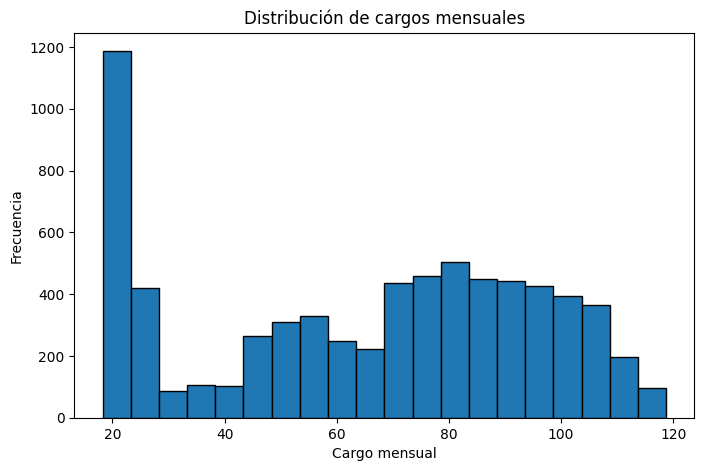

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(df['MonthlyCharges'], bins=20, edgecolor='black')
plt.title('Distribución de cargos mensuales')
plt.xlabel('Cargo mensual')
plt.ylabel('Frecuencia')
plt.show()

**Interpretación:**  
La distribución de `MonthlyCharges` presenta varias concentraciones de clientes según el valor de los cargos mensuales. Se observa un grupo importante con cargos bajos, cercanos a 20 unidades monetarias, y otro conjunto amplio de clientes con cargos ubicados aproximadamente entre 70 y 100.

Esta forma de distribución puede estar relacionada con los diferentes tipos de servicios y planes contratados por los clientes. Por ello, posteriormente será importante analizar si los cargos mensuales presentan diferencias entre los clientes que permanecieron y aquellos que abandonaron el servicio.

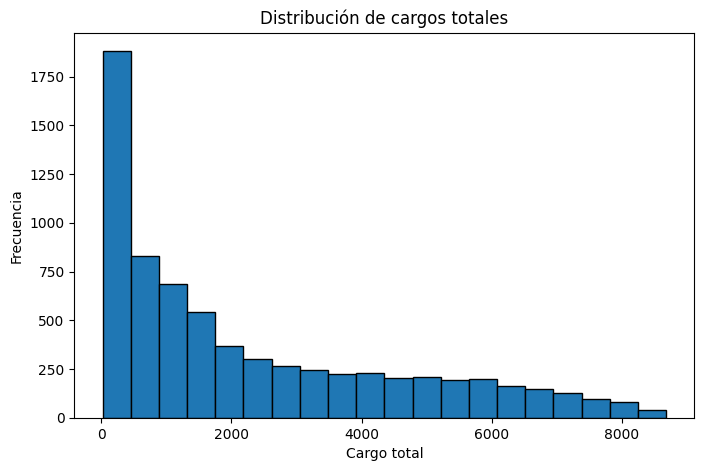

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(totalcharges_numerico.dropna(), bins=20, edgecolor='black')
plt.title('Distribución de cargos totales')
plt.xlabel('Cargo total')
plt.ylabel('Frecuencia')
plt.show()

**Interpretación:**  
La variable `TotalCharges` presenta una distribución claramente asimétrica hacia la derecha. La mayor cantidad de clientes se concentra en valores bajos de cargos acumulados, mientras que la frecuencia disminuye progresivamente conforme aumenta el cargo total.

Este comportamiento coincide con la diferencia observada anteriormente entre la media (2.283,30) y la mediana (1.397,48), donde la media resulta considerablemente mayor. Los valores elevados pueden corresponder a clientes con mayor tiempo de permanencia y no deben considerarse automáticamente como valores atípicos sin realizar un análisis adicional.

### 3.3 Análisis visual de posibles valores atípicos

Se utilizan diagramas de caja para analizar la dispersión de las variables numéricas y detectar visualmente posibles valores atípicos. Posteriormente, estos resultados serán comprobados mediante el método del rango intercuartílico (IQR).

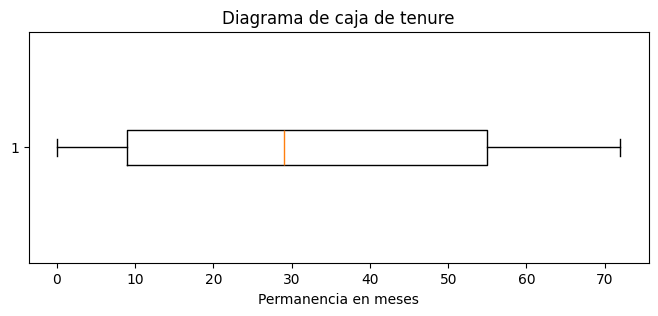

In [24]:
plt.figure(figsize=(8, 3))
plt.boxplot(df['tenure'], vert=False)
plt.title('Diagrama de caja de tenure')
plt.xlabel('Permanencia en meses')
plt.show()

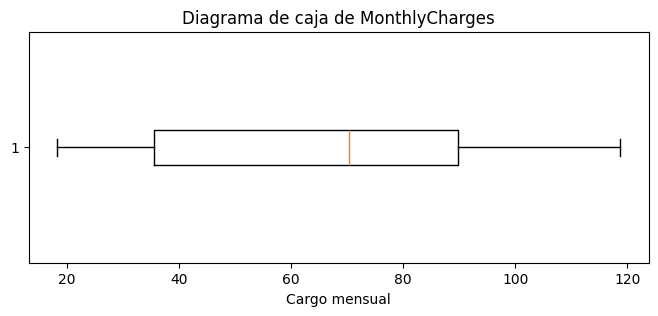

In [25]:
plt.figure(figsize=(8, 3))
plt.boxplot(df['MonthlyCharges'], vert=False)
plt.title('Diagrama de caja de MonthlyCharges')
plt.xlabel('Cargo mensual')
plt.show()

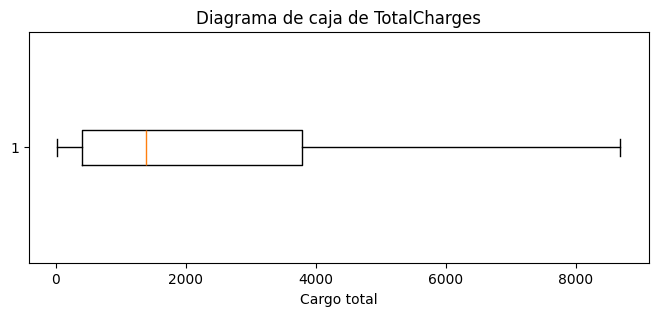

In [26]:
plt.figure(figsize=(8, 3))
plt.boxplot(totalcharges_numerico.dropna(), vert=False)
plt.title('Diagrama de caja de TotalCharges')
plt.xlabel('Cargo total')
plt.show()

**Interpretación:**  
Los diagramas de caja de `tenure`, `MonthlyCharges` y `TotalCharges` no muestran observaciones ubicadas fuera de los límites de los bigotes, por lo que visualmente no se identifican valores atípicos evidentes mediante este método.

En `TotalCharges` se observa una mayor extensión hacia los valores altos, coherente con la asimetría identificada en el histograma; sin embargo, esto no implica necesariamente la existencia de valores atípicos. Para comprobarlo de manera objetiva, se aplica a continuación el método del rango intercuartílico (IQR).

### 3.4 Detección de valores atípicos mediante el rango intercuartílico (IQR)

El rango intercuartílico permite identificar posibles valores atípicos a partir de los cuartiles primero y tercero.

La fórmula utilizada es:

**IQR = Q3 - Q1**

Los límites se calculan mediante:

**Límite inferior = Q1 - 1.5 × IQR**

**Límite superior = Q3 + 1.5 × IQR**

Se considera como posible valor atípico cualquier observación que se encuentre fuera de estos límites.

In [27]:
def detectar_outliers_iqr(serie, nombre):
    datos = serie.dropna()

    Q1 = datos.quantile(0.25)
    Q3 = datos.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = datos[(datos < limite_inferior) | (datos > limite_superior)]

    print(f"Variable: {nombre}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Cantidad de valores atípicos: {len(outliers)}")
    print("-" * 45)

In [28]:
detectar_outliers_iqr(df['tenure'], 'tenure')
detectar_outliers_iqr(df['MonthlyCharges'], 'MonthlyCharges')
detectar_outliers_iqr(totalcharges_numerico, 'TotalCharges')

Variable: tenure
Q1: 9.00
Q3: 55.00
IQR: 46.00
Límite inferior: -60.00
Límite superior: 124.00
Cantidad de valores atípicos: 0
---------------------------------------------
Variable: MonthlyCharges
Q1: 35.50
Q3: 89.85
IQR: 54.35
Límite inferior: -46.02
Límite superior: 171.38
Cantidad de valores atípicos: 0
---------------------------------------------
Variable: TotalCharges
Q1: 401.45
Q3: 3794.74
IQR: 3393.29
Límite inferior: -4688.48
Límite superior: 8884.67
Cantidad de valores atípicos: 0
---------------------------------------------


**Interpretación:**  
La aplicación del método del rango intercuartílico (IQR) confirmó que las variables `tenure`, `MonthlyCharges` y `TotalCharges` no presentan valores atípicos según los límites establecidos.

Para `tenure`, los valores válidos se encuentran dentro del intervalo calculado entre -60 y 124 meses; para `MonthlyCharges`, entre aproximadamente -46,02 y 171,38; y para `TotalCharges`, entre -4.688,48 y 8.884,67. En los tres casos, ninguna observación se encuentra fuera de los límites definidos.

Por lo tanto, no será necesario eliminar ni modificar registros por presencia de valores atípicos. Los valores altos observados en `TotalCharges` corresponden a valores válidos dentro de la distribución y pueden estar relacionados con clientes que presentan mayor tiempo de permanencia.

## 4. Preprocesamiento de datos

En esta etapa se realizan las transformaciones necesarias para preparar el conjunto de datos antes del modelado. Cada modificación se realiza a partir de los problemas identificados durante la exploración y el análisis de calidad de los datos.

### 4.1 Tratamiento de valores faltantes en TotalCharges

Se identificaron 11 registros con espacios vacíos en la variable `TotalCharges`. Antes de aplicar una técnica de tratamiento, se analizan estos registros para determinar la posible causa de los valores faltantes.

In [29]:
registros_vacios = df[df['TotalCharges'].astype(str).str.strip() == '']

registros_vacios[
    ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'Churn']
]

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


In [30]:
registros_vacios['tenure'].value_counts()

,count
tenure,
0,11


In [31]:
print("Permanencia mínima:", registros_vacios['tenure'].min())
print("Permanencia máxima:", registros_vacios['tenure'].max())

Permanencia mínima: 0
Permanencia máxima: 0


**Interpretación:**  
Los 11 registros que presentan valores vacíos en `TotalCharges` corresponden exclusivamente a clientes con `tenure = 0`, es decir, clientes que todavía no registran meses completos de permanencia en la empresa.

Debido a esta característica, los valores faltantes no parecen corresponder a una pérdida aleatoria de información, sino a clientes recientemente incorporados que aún no poseen un cargo total acumulado registrado. Por esta razón, se considera más coherente reemplazar estos valores por 0 en lugar de utilizar medidas como la media o la mediana, ya que estas últimas introducirían valores que no representarían adecuadamente la situación de dichos clientes.

### 4.2 Conversión y tratamiento de la variable TotalCharges

Se crea una copia del conjunto de datos original para conservar los datos iniciales sin modificaciones. Posteriormente, `TotalCharges` se convierte a formato numérico y los 11 valores faltantes correspondientes a clientes con `tenure = 0` se reemplazan por 0.

In [32]:
# Crear una copia del dataset original
df_limpio = df.copy()

# Convertir TotalCharges a formato numérico
df_limpio['TotalCharges'] = pd.to_numeric(
    df_limpio['TotalCharges'],
    errors='coerce'
)

# Identificar los casos faltantes con tenure = 0
condicion = (
    df_limpio['TotalCharges'].isna() &
    (df_limpio['tenure'] == 0)
)

# Reemplazar esos valores por 0
df_limpio.loc[condicion, 'TotalCharges'] = 0

In [33]:
print("Tipo de dato de TotalCharges:", df_limpio['TotalCharges'].dtype)
print("Valores nulos en TotalCharges:", df_limpio['TotalCharges'].isna().sum())
print("Filas del dataset:", df_limpio.shape[0])
print("Columnas del dataset:", df_limpio.shape[1])

Tipo de dato de TotalCharges: float64
Valores nulos en TotalCharges: 0
Filas del dataset: 7043
Columnas del dataset: 21


In [34]:
df_limpio.loc[
    registros_vacios.index,
    ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']
]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,0.0
753,3115-CZMZD,0,20.25,0.0
936,5709-LVOEQ,0,80.85,0.0
1082,4367-NUYAO,0,25.75,0.0
1340,1371-DWPAZ,0,56.05,0.0
3331,7644-OMVMY,0,19.85,0.0
3826,3213-VVOLG,0,25.35,0.0
4380,2520-SGTTA,0,20.00,0.0
5218,2923-ARZLG,0,19.70,0.0
6670,4075-WKNIU,0,73.35,0.0


**Interpretación:**  
La variable `TotalCharges` fue convertida correctamente de tipo `object` a formato numérico (`float64`). Los 11 valores vacíos identificados fueron reemplazados por 0, debido a que correspondían exclusivamente a clientes con cero meses de permanencia.

Después del tratamiento no existen valores nulos en `TotalCharges` y se conservaron los 7.043 registros originales. De esta manera, la variable queda preparada para los análisis posteriores y para su utilización en los modelos de minería de datos.

### 4.3 Creación de variables derivadas mediante Feature Engineering

Con el propósito de enriquecer la información disponible, se generan nuevas variables a partir de características existentes. Estas variables buscan representar de manera más resumida el nivel de contratación de servicios y la antigüedad de los clientes.

Se crean las siguientes variables:

- `NumServices`: representa la cantidad de servicios activos contratados por cada cliente.
- `TenureGroup`: agrupa a los clientes según su tiempo de permanencia en la empresa.

In [35]:
columnas_servicios = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

# Contar servicios cuyo valor sea "Yes"
df_limpio['NumServices'] = (
    df_limpio[columnas_servicios]
    .eq('Yes')
    .sum(axis=1)
)

# Agregar el servicio de Internet cuando exista
df_limpio['NumServices'] += (
    df_limpio['InternetService'] != 'No'
).astype(int)

In [36]:
df_limpio[
    ['PhoneService', 'InternetService', 'NumServices']
].head(10)

,PhoneService,InternetService,NumServices
0,No,DSL,2
1,Yes,DSL,4
2,Yes,DSL,4
3,No,DSL,4
4,Yes,Fiber optic,2
5,Yes,Fiber optic,6
6,Yes,Fiber optic,5
7,No,DSL,2
8,Yes,Fiber optic,7
9,Yes,DSL,4


In [37]:
df_limpio['TenureGroup'] = pd.cut(
    df_limpio['tenure'],
    bins=[-1, 12, 48, float('inf')],
    labels=['Nuevo', 'Intermedio', 'Antiguo']
)

In [38]:
df_limpio[
    ['tenure', 'TenureGroup', 'NumServices']
].head(15)

,tenure,TenureGroup,NumServices
0,1,Nuevo,2
1,34,Intermedio,4
2,2,Nuevo,4
3,45,Intermedio,4
4,2,Nuevo,2
5,8,Nuevo,6
6,22,Intermedio,5
7,10,Nuevo,2
8,28,Intermedio,7
9,62,Antiguo,4


In [39]:
df_limpio['TenureGroup'].value_counts()

,count
TenureGroup,
Intermedio,2618
Antiguo,2239
Nuevo,2186


In [40]:
df_limpio['NumServices'].describe()

,NumServices
count,7043.000000
mean,4.146244
std,2.312720
min,1.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,9.000000


In [41]:
print("Filas:", df_limpio.shape[0])
print("Columnas:", df_limpio.shape[1])

Filas: 7043
Columnas: 23


**Interpretación:**  
Mediante técnicas de *feature engineering* se generaron dos nuevas variables, aumentando el conjunto de datos de 21 a 23 columnas sin modificar la cantidad de 7.043 registros.

La variable `TenureGroup` permitió clasificar a los clientes según su tiempo de permanencia. Se identificaron 2.186 clientes nuevos, 2.618 clientes con permanencia intermedia y 2.239 clientes antiguos. Esta variable facilitará posteriormente el análisis de la relación entre la antigüedad del cliente y el abandono del servicio.

Por otra parte, `NumServices` resume la cantidad de servicios activos contratados por cada cliente. Los clientes poseen entre 1 y 9 servicios, con un promedio aproximado de 4,15 y una mediana de 4 servicios. Esta nueva característica permitirá evaluar si la cantidad de servicios contratados se encuentra relacionada con la permanencia o el abandono de los clientes.

### 4.4 Relación de las variables derivadas con Churn

Se analiza la relación entre las variables creadas mediante *feature engineering* y la variable objetivo `Churn`, con el propósito de determinar si aportan información relevante sobre el comportamiento de abandono de los clientes.

In [42]:
tabla_tenure_churn = pd.crosstab(
    df_limpio['TenureGroup'],
    df_limpio['Churn'],
    normalize='index'
) * 100

tabla_tenure_churn.round(2)

Churn,No,Yes
TenureGroup,,
Nuevo,52.56,47.44
Intermedio,76.36,23.64
Antiguo,90.49,9.51


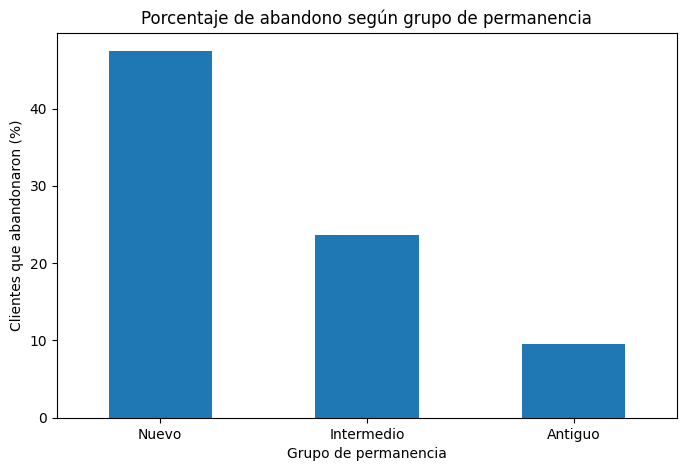

In [43]:
tabla_tenure_churn['Yes'].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Porcentaje de abandono según grupo de permanencia')
plt.xlabel('Grupo de permanencia')
plt.ylabel('Clientes que abandonaron (%)')
plt.xticks(rotation=0)
plt.show()

**Interpretación:**  
La antigüedad del cliente presenta una relación clara con el abandono del servicio. Entre los clientes clasificados como nuevos, el 47,44 % abandonó la empresa, mientras que en los clientes de permanencia intermedia la tasa disminuye al 23,64 %. En los clientes antiguos, el abandono se reduce considerablemente hasta el 9,51 %.

Estos resultados sugieren que el riesgo de abandono es considerablemente mayor durante los primeros meses de relación con la empresa y disminuye conforme aumenta el tiempo de permanencia. Por lo tanto, `TenureGroup` constituye una variable potencialmente relevante para el modelo predictivo y para la formulación de estrategias de fidelización.

In [44]:
df_limpio.groupby('Churn')['NumServices'].agg(
    ['count', 'mean', 'median', 'std']
).round(2)

,count,mean,median,std
Churn,,,,
No,5174,4.17,4.0,2.46
Yes,1869,4.07,4.0,1.84


In [45]:
churn_por_servicios = pd.crosstab(
    df_limpio['NumServices'],
    df_limpio['Churn'],
    normalize='index'
) * 100

churn_por_servicios.round(2)

Churn,No,Yes
NumServices,,
1,89.08,10.92
2,69.03,30.97
3,55.08,44.92
4,63.52,36.48
5,68.66,31.34
6,74.45,25.55
7,77.51,22.49
8,87.59,12.41
9,94.71,5.29


**Interpretación:**  
Los clientes que permanecieron en la empresa poseen en promedio 4,17 servicios, mientras que aquellos que abandonaron presentan un promedio de 4,07. Las medianas son iguales a 4 servicios, por lo que la diferencia promedio entre ambos grupos es reducida.

Sin embargo, al analizar la tasa de abandono para cada cantidad de servicios se observa un comportamiento no lineal. Los clientes con tres servicios presentan la mayor tasa de abandono (44,92 %), seguidos por quienes poseen cuatro servicios (36,48 %) y cinco servicios (31,34 %). A partir de seis servicios la tasa de abandono disminuye progresivamente, llegando al 5,29 % entre los clientes con nueve servicios.

Por lo tanto, la cantidad de servicios por sí sola no presenta una relación lineal con el abandono, pero permite identificar determinados niveles de contratación asociados con diferentes tasas de `Churn`.

### 4.5 Análisis de variables relevantes respecto al abandono

Se analizan algunas variables originales del conjunto de datos frente a la variable objetivo `Churn`, con el propósito de identificar patrones asociados al abandono antes de construir los modelos predictivos.

In [46]:
churn_contrato = pd.crosstab(
    df_limpio['Contract'],
    df_limpio['Churn'],
    normalize='index'
) * 100

churn_contrato.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


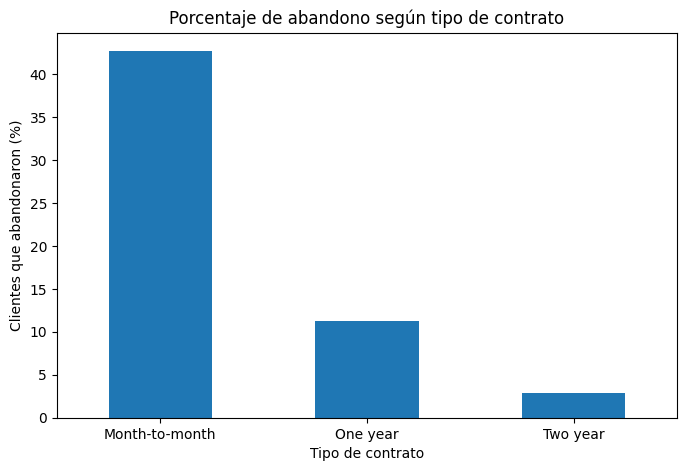

In [47]:
churn_contrato['Yes'].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Porcentaje de abandono según tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Clientes que abandonaron (%)')
plt.xticks(rotation=0)
plt.show()

**Interpretación:**  
El tipo de contrato presenta una relación importante con el abandono de clientes. Los clientes con contratos mes a mes (`Month-to-month`) presentan una tasa de abandono del 42,71 %, considerablemente superior a la observada en los contratos de un año (11,27 %) y de dos años (2,83 %).

Los resultados sugieren que los clientes con compromisos contractuales de mayor duración presentan una mayor permanencia en la empresa. Por tanto, la modalidad de contrato constituye una característica potencialmente relevante para la predicción de `Churn`.

In [48]:
churn_internet = pd.crosstab(
    df_limpio['InternetService'],
    df_limpio['Churn'],
    normalize='index'
) * 100

churn_internet.round(2)

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


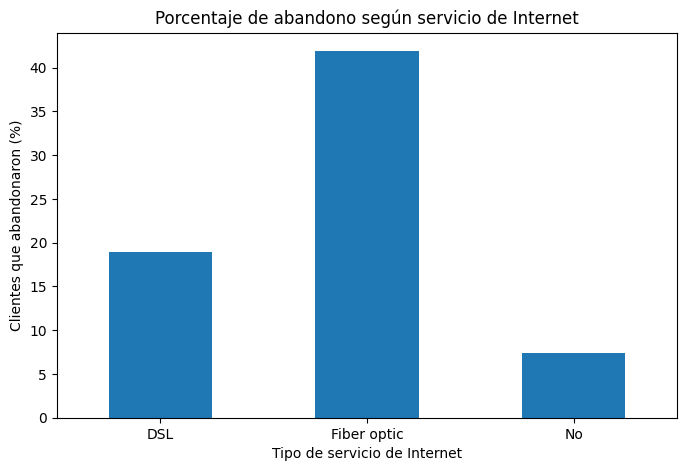

In [49]:
churn_internet['Yes'].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Porcentaje de abandono según servicio de Internet')
plt.xlabel('Tipo de servicio de Internet')
plt.ylabel('Clientes que abandonaron (%)')
plt.xticks(rotation=0)
plt.show()

**Interpretación:**  
El tipo de servicio de Internet también presenta diferencias relevantes respecto al abandono. Los clientes que utilizan fibra óptica registran la mayor tasa de abandono, con un 41,89 %, mientras que los usuarios de DSL presentan una tasa del 18,96 %. Los clientes que no poseen servicio de Internet muestran la menor tasa, con un 7,40 %.

Estos resultados indican que el tipo de servicio de Internet puede aportar información relevante al modelo predictivo. En particular, será necesario considerar la elevada proporción de abandono observada entre los usuarios de fibra óptica.

In [50]:
df_limpio.groupby('Churn')['MonthlyCharges'].agg(
    ['count', 'mean', 'median', 'std']
).round(2)

,count,mean,median,std
Churn,,,,
No,5174,61.27,64.43,31.09
Yes,1869,74.44,79.65,24.67


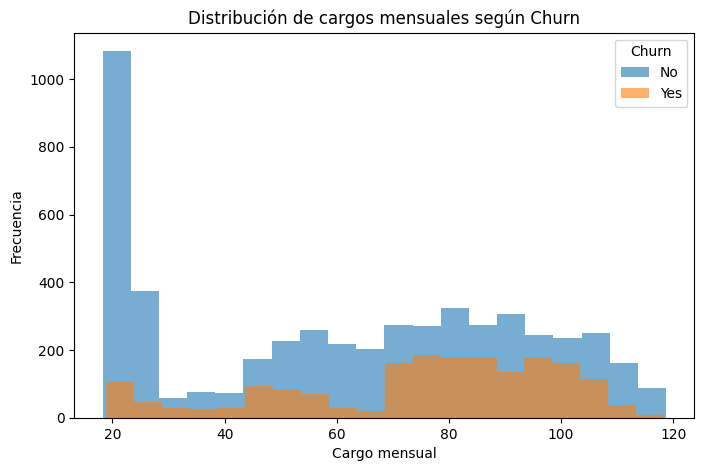

In [51]:
plt.figure(figsize=(8, 5))

df_limpio[df_limpio['Churn'] == 'No']['MonthlyCharges'].plot(
    kind='hist',
    bins=20,
    alpha=0.6,
    label='No'
)

df_limpio[df_limpio['Churn'] == 'Yes']['MonthlyCharges'].plot(
    kind='hist',
    bins=20,
    alpha=0.6,
    label='Yes'
)

plt.title('Distribución de cargos mensuales según Churn')
plt.xlabel('Cargo mensual')
plt.ylabel('Frecuencia')
plt.legend(title='Churn')
plt.show()

**Interpretación:**  
Los clientes que abandonaron la empresa presentan cargos mensuales superiores a los clientes que permanecieron. El grupo con `Churn = Yes` registra un cargo mensual promedio de 74,44 y una mediana de 79,65, mientras que los clientes que permanecieron presentan un promedio de 61,27 y una mediana de 64,43.

La distribución gráfica también muestra una mayor presencia de clientes que abandonaron en rangos de cargos mensuales medios y altos. Esto sugiere que `MonthlyCharges` puede contribuir a explicar el comportamiento de abandono, aunque será necesario analizar esta variable conjuntamente con otras características mediante los modelos predictivos.

## 5. Preparación de los datos para el modelado

Una vez completadas las etapas de exploración, limpieza y transformación, se prepara el conjunto de datos para la construcción de los modelos predictivos.

### 5.1 Definición de variables predictoras y variable objetivo

La variable objetivo corresponde a `Churn`, que indica si un cliente abandonó (`Yes`) o permaneció (`No`) en la empresa.

La variable `customerID` se excluye del modelado debido a que constituye únicamente un identificador único de cada cliente y no representa una característica relacionada directamente con su comportamiento de abandono.

In [52]:
X = df_limpio.drop(columns=['customerID', 'Churn'])

y = df_limpio['Churn'].map({
    'No': 0,
    'Yes': 1
})

In [53]:
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

print("\nDistribución de la variable objetivo:")
print(y.value_counts())

Dimensiones de X: (7043, 21)
Dimensiones de y: (7043,)

Distribución de la variable objetivo:
Churn
0    5174
1    1869
Name: count, dtype: int64


**Interpretación:**  
Después de excluir `customerID` y separar la variable objetivo `Churn`, el conjunto de variables predictoras `X` quedó conformado por 7.043 registros y 21 características. La variable objetivo `y` contiene igualmente 7.043 observaciones y fue transformada a formato binario, donde 0 representa a los clientes que permanecieron y 1 a los clientes que abandonaron el servicio.

La distribución de la variable objetivo mantiene los 5.174 casos de permanencia y 1.869 casos de abandono identificados durante el análisis exploratorio.

### 5.2 Identificación de variables numéricas y categóricas

Antes de aplicar técnicas de codificación y normalización, se identifican las variables numéricas y categóricas presentes en el conjunto de datos.

Las variables numéricas podrán ser utilizadas directamente por los algoritmos, aunque algunas requerirán posteriormente un proceso de escalado. En cambio, las variables categóricas deberán transformarse a una representación numérica antes de ser utilizadas en los modelos predictivos.

Esta clasificación permitirá aplicar un preprocesamiento adecuado a cada tipo de variable.

In [54]:
columnas_numericas = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

columnas_categoricas = X.select_dtypes(
    exclude=['int64', 'float64']
).columns.tolist()

print("Variables numéricas:")
print(columnas_numericas)

print("\nVariables categóricas:")
print(columnas_categoricas)

print("\nCantidad de variables numéricas:", len(columnas_numericas))
print("Cantidad de variables categóricas:", len(columnas_categoricas))

Variables numéricas:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices']

Variables categóricas:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']

Cantidad de variables numéricas: 5
Cantidad de variables categóricas: 16


**Interpretación:**  
De las 21 variables predictoras, se identificaron 5 variables numéricas y 16 variables categóricas. Esta diferenciación es necesaria debido a que los algoritmos de aprendizaje automático requieren representaciones numéricas para realizar el entrenamiento.

Las variables categóricas deberán ser codificadas antes del modelado, mientras que las variables numéricas podrán ser escaladas cuando el algoritmo utilizado sea sensible a las diferencias de magnitud entre las características.

### 5.3 División del conjunto de datos en entrenamiento y prueba

El conjunto de datos se divide en dos subconjuntos: 80 % para entrenamiento y 20 % para prueba.

El conjunto de entrenamiento será utilizado para ajustar los modelos de clasificación, mientras que el conjunto de prueba permitirá evaluar su capacidad de generalización sobre datos que no fueron utilizados durante el entrenamiento.

Se utiliza `random_state=42` para garantizar la reproducibilidad de la división y `stratify=y` para conservar aproximadamente la proporción original de las clases de la variable objetivo `Churn` tanto en el conjunto de entrenamiento como en el conjunto de prueba.

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [57]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 21)
X_test: (1409, 21)
y_train: (5634,)
y_test: (1409,)


**Interpretación:**  
El conjunto de datos fue dividido en 5.634 registros para entrenamiento y 1.409 registros para prueba, equivalentes aproximadamente al 80 % y 20 % del total, respectivamente.

Ambos subconjuntos conservan las 21 variables predictoras. La división estratificada permite mantener aproximadamente la proporción original de las clases de `Churn`, mientras que `random_state=42` garantiza que los resultados puedan reproducirse en futuras ejecuciones.

### 5.4 Codificación de variables categóricas y escalado de variables numéricas

Los algoritmos de aprendizaje automático requieren que las características utilizadas durante el entrenamiento se encuentren representadas numéricamente.

Para las variables categóricas se aplica codificación One-Hot Encoding, mediante la cual cada categoría se transforma en una o varias variables binarias.

Para las variables numéricas se utiliza StandardScaler, que transforma las características para que presenten una escala comparable. Este procedimiento resulta especialmente importante para modelos sensibles a la magnitud de las variables, como la regresión logística.

El preprocesamiento se implementa mediante `ColumnTransformer`, permitiendo aplicar diferentes transformaciones según el tipo de variable y conservar el mismo procedimiento para futuros datos utilizados por el modelo.

In [58]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [59]:
preprocesador = ColumnTransformer(
    transformers=[
        (
            'numericas',
            StandardScaler(),
            columnas_numericas
        ),
        (
            'categoricas',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            columnas_categoricas
        )
    ]
)

In [60]:
print(preprocesador)

ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges', 'NumServices']),
                                ('categoricas',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod',
                                  'TenureGroup'])])


## 6. Construcción de modelos de clasificación

Para predecir el abandono de clientes se implementan dos algoritmos de aprendizaje supervisado: Regresión Logística y Random Forest.

La Regresión Logística permite estimar la probabilidad de pertenencia a una de las dos clases de la variable objetivo, mientras que Random Forest combina múltiples árboles de decisión para generar una clasificación final.

Ambos modelos utilizarán el mismo procedimiento de preprocesamiento mediante un `Pipeline`, garantizando que la codificación de las variables categóricas y el escalado de las variables numéricas se apliquen de manera consistente durante el entrenamiento y posteriormente sobre nuevos datos.

### 6.1 Modelo de Regresión Logística

Se construye un modelo de Regresión Logística como primera técnica de clasificación. El modelo se integra con el preprocesamiento previamente definido mediante un `Pipeline`, permitiendo realizar automáticamente la transformación de los datos antes del entrenamiento.

Se utiliza `max_iter=1000` para proporcionar al algoritmo un número suficiente de iteraciones para alcanzar la convergencia.

In [61]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [62]:
modelo_logistico = Pipeline(
    steps=[
        ('preprocesamiento', preprocesador),
        ('modelo', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [63]:
modelo_logistico.fit(X_train, y_train)

print("Modelo de Regresión Logística entrenado correctamente.")

Modelo de Regresión Logística entrenado correctamente.


### 6.2 Modelo Random Forest

Como segunda técnica se utiliza Random Forest, un algoritmo basado en múltiples árboles de decisión. Cada árbol realiza una clasificación y el conjunto combina sus resultados para determinar la predicción final.

El modelo utiliza 200 árboles (`n_estimators=200`) y `random_state=42` para garantizar la reproducibilidad de los resultados. Al igual que en la Regresión Logística, se integra el preprocesamiento mediante un `Pipeline`.

In [64]:
from sklearn.ensemble import RandomForestClassifier

In [65]:
modelo_random_forest = Pipeline(
    steps=[
        ('preprocesamiento', preprocesador),
        ('modelo', RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

In [66]:
modelo_random_forest.fit(X_train, y_train)

print("Modelo Random Forest entrenado correctamente.")

Modelo Random Forest entrenado correctamente.


## 7. Validación cruzada y comparación de modelos

Para evaluar la estabilidad y capacidad de generalización de los modelos se aplica validación cruzada estratificada con 5 particiones (`cv = 5`).

En cada iteración, una parte de los datos se utiliza para validación y las restantes para entrenamiento. Este procedimiento permite obtener una evaluación más confiable que utilizar una única división de los datos.

Debido al desequilibrio observado en la variable objetivo `Churn`, se emplean dos métricas principales:

- **Accuracy:** representa la proporción total de predicciones correctas.
- **F1-Score:** combina Precision y Recall, proporcionando una evaluación más equilibrada del desempeño sobre la clase de abandono.

Los resultados obtenidos mediante ambos modelos serán comparados para identificar cuál presenta un mejor comportamiento predictivo.

In [67]:
from sklearn.model_selection import cross_validate, StratifiedKFold

In [68]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [69]:
metricas = {
    'accuracy': 'accuracy',
    'f1': 'f1'
}

### 7.1 Validación cruzada de Regresión Logística

Se evalúa el modelo de Regresión Logística mediante validación cruzada estratificada de 5 particiones, utilizando Accuracy y F1-Score como métricas principales.

In [70]:
resultados_logistico = cross_validate(
    modelo_logistico,
    X_train,
    y_train,
    cv=cv,
    scoring=metricas
)

accuracy_logistico = resultados_logistico['test_accuracy'].mean()
f1_logistico = resultados_logistico['test_f1'].mean()

print("Regresión Logística")
print("Accuracy promedio:", round(accuracy_logistico, 4))
print("F1-Score promedio:", round(f1_logistico, 4))

Regresión Logística
Accuracy promedio: 0.808
F1-Score promedio: 0.5977


### 7.2 Validación cruzada de Random Forest

Se aplica el mismo procedimiento de validación cruzada al modelo Random Forest, utilizando las mismas cinco particiones y métricas para garantizar una comparación equivalente entre ambos modelos.

In [71]:
resultados_rf = cross_validate(
    modelo_random_forest,
    X_train,
    y_train,
    cv=cv,
    scoring=metricas
)

accuracy_rf = resultados_rf['test_accuracy'].mean()
f1_rf = resultados_rf['test_f1'].mean()

print("Random Forest")
print("Accuracy promedio:", round(accuracy_rf, 4))
print("F1-Score promedio:", round(f1_rf, 4))

Random Forest
Accuracy promedio: 0.7883
F1-Score promedio: 0.545


### 7.3 Comparación de resultados

Se construye una tabla comparativa con los valores promedio de Accuracy y F1-Score obtenidos mediante validación cruzada, con el propósito de identificar el modelo con mejor desempeño.

In [72]:
comparacion_modelos = pd.DataFrame({
    'Modelo': [
        'Regresión Logística',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_logistico,
        accuracy_rf
    ],
    'F1-Score': [
        f1_logistico,
        f1_rf
    ]
})

comparacion_modelos[['Accuracy', 'F1-Score']] = (
    comparacion_modelos[['Accuracy', 'F1-Score']]
    .round(4)
)

comparacion_modelos

,Modelo,Accuracy,F1-Score
0,Regresión Logística,0.8080,0.5977
1,Random Forest,0.7883,0.5450


**Interpretación:**  
Los resultados de la validación cruzada muestran que la Regresión Logística obtuvo un Accuracy promedio de 0,8080 y un F1-Score de 0,5977, mientras que Random Forest alcanzó un Accuracy de 0,7883 y un F1-Score de 0,5450.

En esta primera comparación, la Regresión Logística presenta un mejor desempeño en ambas métricas. La diferencia observada en F1-Score es especialmente relevante debido al desequilibrio existente en la variable objetivo, ya que esta métrica considera conjuntamente Precision y Recall para la clase positiva correspondiente a los clientes que abandonan el servicio.

No obstante, la selección definitiva del modelo se realizará después de evaluar ambos algoritmos sobre el conjunto de prueba independiente.

## 8. Evaluación de los modelos sobre el conjunto de prueba

Una vez realizada la validación cruzada, se evalúan los modelos sobre el conjunto de prueba, compuesto por 1.409 registros que no fueron utilizados durante el entrenamiento.

Para realizar una evaluación integral se utilizan las métricas Accuracy, Precision, Recall y F1-Score. Además, se construye una matriz de confusión para identificar la cantidad de predicciones correctas e incorrectas realizadas por cada modelo.

In [73]:
pred_logistico = modelo_logistico.predict(X_test)
pred_rf = modelo_random_forest.predict(X_test)

In [74]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

### 8.1 Evaluación de la Regresión Logística

Se evalúan las predicciones realizadas por el modelo de Regresión Logística sobre el conjunto de prueba mediante Accuracy, Precision, Recall y F1-Score.

In [75]:
accuracy_test_log = accuracy_score(y_test, pred_logistico)
precision_test_log = precision_score(y_test, pred_logistico)
recall_test_log = recall_score(y_test, pred_logistico)
f1_test_log = f1_score(y_test, pred_logistico)

print("Regresión Logística")
print("Accuracy:", round(accuracy_test_log, 4))
print("Precision:", round(precision_test_log, 4))
print("Recall:", round(recall_test_log, 4))
print("F1-Score:", round(f1_test_log, 4))

Regresión Logística
Accuracy: 0.8013
Precision: 0.6567
Recall: 0.5267
F1-Score: 0.5846


In [76]:
print(classification_report(
    y_test,
    pred_logistico,
    target_names=['No abandona', 'Abandona']
))

              precision    recall  f1-score   support

 No abandona       0.84      0.90      0.87      1035
    Abandona       0.66      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



**Interpretación:**  
La Regresión Logística alcanzó una exactitud (Accuracy) de 0,8013, lo que indica que aproximadamente el 80,13 % de los 1.409 clientes del conjunto de prueba fueron clasificados correctamente.

Para la clase correspondiente al abandono del servicio, el modelo obtuvo una Precision de 0,6567, lo que significa que aproximadamente el 65,67 % de los clientes identificados por el modelo como posibles abandonos realmente pertenecían a esta clase.

El Recall fue de 0,5267, indicando que el modelo logró identificar aproximadamente el 52,67 % de los clientes que efectivamente abandonaron el servicio. Finalmente, el F1-Score alcanzó 0,5846, reflejando el equilibrio entre Precision y Recall.

Los resultados muestran un desempeño adecuado de clasificación general, aunque todavía existe dificultad para identificar todos los casos reales de abandono.

### 8.2 Matriz de confusión de la Regresión Logística

La matriz de confusión permite identificar los casos correctamente clasificados y los errores cometidos por el modelo al predecir clientes que permanecen o abandonan el servicio.

In [77]:
matriz_log = confusion_matrix(y_test, pred_logistico)

print(matriz_log)

[[932 103]
 [177 197]]


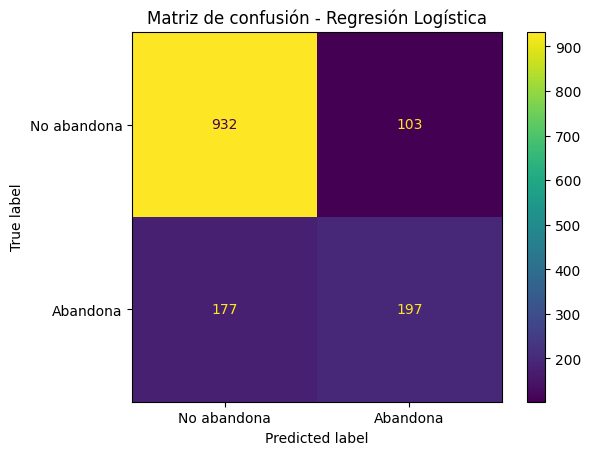

In [78]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=matriz_log,
    display_labels=['No abandona', 'Abandona']
).plot()

plt.title('Matriz de confusión - Regresión Logística')
plt.show()

**Interpretación de la matriz de confusión:**  
La Regresión Logística clasificó correctamente a 932 clientes que permanecieron en la empresa y a 197 clientes que efectivamente abandonaron el servicio.

El modelo también produjo 103 falsos positivos, correspondientes a clientes que fueron clasificados como posibles abandonos aunque realmente permanecieron, y 177 falsos negativos, correspondientes a clientes que abandonaron el servicio pero que el modelo no logró identificar.

Desde una perspectiva empresarial, los falsos negativos son especialmente relevantes, debido a que representan clientes en riesgo de abandono que no serían detectados anticipadamente por el sistema.

### 8.3 Evaluación de Random Forest

El modelo Random Forest se evalúa sobre el mismo conjunto de prueba y utilizando las mismas métricas, permitiendo realizar una comparación equivalente con la Regresión Logística.

In [79]:
accuracy_test_rf = accuracy_score(y_test, pred_rf)
precision_test_rf = precision_score(y_test, pred_rf)
recall_test_rf = recall_score(y_test, pred_rf)
f1_test_rf = f1_score(y_test, pred_rf)

print("Random Forest")
print("Accuracy:", round(accuracy_test_rf, 4))
print("Precision:", round(precision_test_rf, 4))
print("Recall:", round(recall_test_rf, 4))
print("F1-Score:", round(f1_test_rf, 4))

Random Forest
Accuracy: 0.7786
Precision: 0.6062
Recall: 0.4733
F1-Score: 0.5315


**Interpretación:**  
Random Forest obtuvo un Accuracy de 0,7786, clasificando correctamente aproximadamente el 77,86 % de los clientes del conjunto de prueba.

Para la clase de abandono alcanzó una Precision de 0,6062 y un Recall de 0,4733. Esto indica que aproximadamente el 60,62 % de los clientes identificados como posibles abandonos realmente abandonaron el servicio, mientras que el modelo detectó únicamente el 47,33 % de todos los abandonos reales.

El F1-Score fue de 0,5315. Al comparar estos resultados con los obtenidos mediante Regresión Logística, Random Forest presenta un desempeño inferior en las cuatro métricas evaluadas.

In [80]:
print(classification_report(
    y_test,
    pred_rf,
    target_names=['No abandona', 'Abandona']
))

              precision    recall  f1-score   support

 No abandona       0.82      0.89      0.86      1035
    Abandona       0.61      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



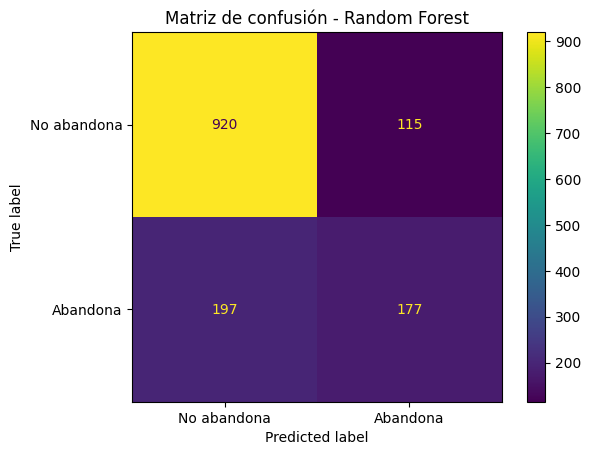

In [81]:
matriz_rf = confusion_matrix(y_test, pred_rf)

ConfusionMatrixDisplay(
    confusion_matrix=matriz_rf,
    display_labels=['No abandona', 'Abandona']
).plot()

plt.title('Matriz de confusión - Random Forest')
plt.show()

**Interpretación de la matriz de confusión:**  
Random Forest clasificó correctamente a 920 clientes que permanecieron y a 177 clientes que abandonaron el servicio.

Sin embargo, generó 115 falsos positivos y 197 falsos negativos. En comparación con la Regresión Logística, Random Forest identifica una menor cantidad de abandonos reales y genera una mayor cantidad de falsos negativos, lo cual reduce su capacidad para detectar clientes en riesgo.

### 8.4 Comparación final de los modelos

Se comparan las métricas obtenidas por ambos modelos sobre el conjunto de prueba para determinar cuál ofrece el mejor equilibrio entre predicciones correctas y capacidad para identificar clientes que abandonan el servicio.

In [82]:
comparacion_test = pd.DataFrame({
    'Modelo': [
        'Regresión Logística',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_test_log,
        accuracy_test_rf
    ],
    'Precision': [
        precision_test_log,
        precision_test_rf
    ],
    'Recall': [
        recall_test_log,
        recall_test_rf
    ],
    'F1-Score': [
        f1_test_log,
        f1_test_rf
    ]
})

comparacion_test[['Accuracy', 'Precision', 'Recall', 'F1-Score']] = (
    comparacion_test[
        ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    ].round(4)
)

comparacion_test

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regresión Logística,0.8013,0.6567,0.5267,0.5846
1,Random Forest,0.7786,0.6062,0.4733,0.5315


**Interpretación:**  
La comparación final evidencia que la Regresión Logística presenta un mejor desempeño que Random Forest en todas las métricas analizadas.

La Regresión Logística obtuvo un Accuracy de 0,8013 frente a 0,7786 de Random Forest; una Precision de 0,6567 frente a 0,6062; un Recall de 0,5267 frente a 0,4733; y un F1-Score de 0,5846 frente a 0,5315.

Además, los resultados son consistentes con la validación cruzada realizada previamente, donde la Regresión Logística también obtuvo mejores valores promedio de Accuracy y F1-Score.

Por estas razones, la Regresión Logística es seleccionada como el modelo principal para continuar con la interpretación, almacenamiento y posterior despliegue mediante una API y una aplicación web.

## 9. Evaluación mediante curva ROC y AUC

Como evaluación complementaria del modelo seleccionado, se utiliza la curva ROC (Receiver Operating Characteristic) y el área bajo la curva (AUC).

La curva ROC representa la relación entre la tasa de verdaderos positivos y la tasa de falsos positivos para diferentes umbrales de clasificación. El valor AUC resume la capacidad general del modelo para diferenciar entre clientes que abandonan y clientes que permanecen.

Un valor de AUC cercano a 1 representa una mayor capacidad discriminativa, mientras que un valor cercano a 0,5 indica un comportamiento similar a una clasificación aleatoria.

In [83]:
prob_logistico = modelo_logistico.predict_proba(X_test)[:, 1]

In [84]:
from sklearn.metrics import roc_curve, roc_auc_score

In [85]:
auc_logistico = roc_auc_score(y_test, prob_logistico)

print("AUC - Regresión Logística:", round(auc_logistico, 4))

AUC - Regresión Logística: 0.8413


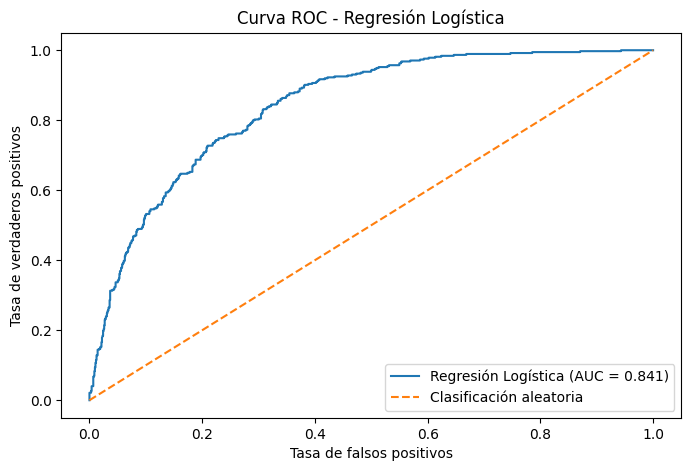

In [86]:
fpr, tpr, thresholds = roc_curve(y_test, prob_logistico)

plt.figure(figsize=(8, 5))

plt.plot(
    fpr,
    tpr,
    label=f'Regresión Logística (AUC = {auc_logistico:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Clasificación aleatoria'
)

plt.title('Curva ROC - Regresión Logística')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.legend()
plt.show()

**Interpretación:**  
La Regresión Logística obtuvo un valor AUC de 0,8413. Este resultado indica que el modelo presenta una buena capacidad para diferenciar entre clientes que permanecen y clientes que abandonan el servicio.

La curva ROC se mantiene claramente por encima de la línea diagonal correspondiente a una clasificación aleatoria (AUC = 0,5), evidenciando que el modelo posee capacidad predictiva superior al azar.

Por tanto, el resultado de AUC respalda la selección de la Regresión Logística como modelo principal, complementando los resultados previamente obtenidos mediante Accuracy, Precision, Recall, F1-Score y validación cruzada.

## 10. Interpretación de las variables del modelo seleccionado

Una vez seleccionada la Regresión Logística como modelo principal, se analizan sus coeficientes con el propósito de identificar las características asociadas con una mayor o menor probabilidad de abandono.

En la Regresión Logística, los coeficientes positivos se relacionan con un incremento en la probabilidad estimada de pertenecer a la clase `Churn = 1`, mientras que los coeficientes negativos se relacionan con una disminución de dicha probabilidad.

La magnitud de los coeficientes permite analizar la influencia relativa de las características dentro del modelo.

### 10.1 Análisis de coeficientes de la Regresión Logística

Para interpretar el modelo seleccionado se analizan los coeficientes generados por la Regresión Logística después del proceso de preprocesamiento y codificación de las variables.

En este tipo de modelo, un coeficiente positivo se asocia con un incremento en la probabilidad estimada de que un cliente abandone el servicio (`Churn = 1`), mientras que un coeficiente negativo se relaciona con una disminución de dicha probabilidad.

La magnitud absoluta del coeficiente permite identificar qué características presentan una mayor influencia dentro del modelo. Sin embargo, estos valores deben interpretarse considerando que el modelo analiza simultáneamente todas las variables, por lo que no representan relaciones causales directas.

In [87]:
# Obtener el preprocesador ya ajustado dentro del modelo
preprocesador_ajustado = modelo_logistico.named_steps['preprocesamiento']

# Obtener los nombres de las características después del One-Hot Encoding
nombres_variables = preprocesador_ajustado.get_feature_names_out()

print("Cantidad de variables después del preprocesamiento:",
      len(nombres_variables))

Cantidad de variables después del preprocesamiento: 49


In [88]:
coeficientes = modelo_logistico.named_steps['modelo'].coef_[0]

importancia_logistica = pd.DataFrame({
    'Variable': nombres_variables,
    'Coeficiente': coeficientes
})

# Simplificar los nombres
importancia_logistica['Variable'] = (
    importancia_logistica['Variable']
    .str.replace('numericas__', '', regex=False)
    .str.replace('categoricas__', '', regex=False)
)

# Magnitud del coeficiente
importancia_logistica['Importancia_abs'] = (
    importancia_logistica['Coeficiente'].abs()
)

importancia_logistica = importancia_logistica.sort_values(
    'Importancia_abs',
    ascending=False
)

importancia_logistica.head(15)

,Variable,Coeficiente,Importancia_abs
1,tenure,-0.976744,0.976744
39,Contract_Two year,-0.851059,0.851059
16,InternetService_DSL,-0.693179,0.693179
17,InternetService_Fiber optic,0.658881,0.658881
37,Contract_Month-to-month,0.641872,0.641872
2,MonthlyCharges,-0.577955,0.577955
47,TenureGroup_Intermedio,-0.373085,0.373085
40,PaperlessBilling_No,-0.331856,0.331856
4,NumServices,0.305698,0.305698
23,OnlineBackup_No internet service,-0.252190,0.252190


In [89]:
mayor_abandono = importancia_logistica.sort_values(
    'Coeficiente',
    ascending=False
).head(10)

mayor_abandono[
    ['Variable', 'Coeficiente']
]

,Variable,Coeficiente
17,InternetService_Fiber optic,0.658881
37,Contract_Month-to-month,0.641872
4,NumServices,0.305698
3,TotalCharges,0.213121
19,OnlineSecurity_No,0.200471
44,PaymentMethod_Electronic check,0.195739
28,TechSupport_No,0.169053
33,StreamingTV_Yes,0.145162
36,StreamingMovies_Yes,0.143923
46,TenureGroup_Antiguo,0.084797


In [90]:
menor_abandono = importancia_logistica.sort_values(
    'Coeficiente'
).head(10)

menor_abandono[
    ['Variable', 'Coeficiente']
]

,Variable,Coeficiente
1,tenure,-0.976744
39,Contract_Two year,-0.851059
16,InternetService_DSL,-0.693179
2,MonthlyCharges,-0.577955
47,TenureGroup_Intermedio,-0.373085
40,PaperlessBilling_No,-0.331856
20,OnlineSecurity_No internet service,-0.252190
23,OnlineBackup_No internet service,-0.252190
26,DeviceProtection_No internet service,-0.252190
35,StreamingMovies_No internet service,-0.252190


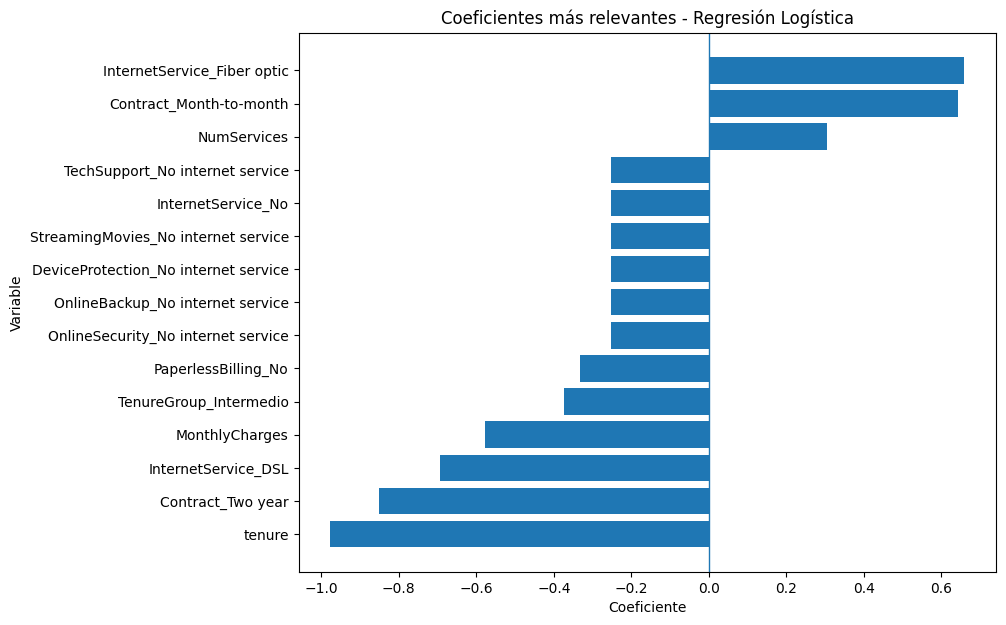

In [91]:
top_variables = importancia_logistica.head(15).sort_values(
    'Coeficiente'
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_variables['Variable'],
    top_variables['Coeficiente']
)

plt.axvline(0, linewidth=1)

plt.title('Coeficientes más relevantes - Regresión Logística')
plt.xlabel('Coeficiente')
plt.ylabel('Variable')
plt.show()

**Interpretación:**  
El análisis de los coeficientes de la Regresión Logística permite identificar características asociadas con aumentos o disminuciones en la probabilidad estimada de abandono, considerando simultáneamente el resto de variables incluidas en el modelo.

Entre los coeficientes positivos más relevantes se encuentran el servicio de Internet por fibra óptica (`InternetService_Fiber optic`) y el contrato mensual (`Contract_Month-to-month`). Estos resultados coinciden con el análisis exploratorio, donde los clientes con fibra óptica presentaron una tasa de abandono del 41,89 % y quienes tenían contratos mensuales alcanzaron el 42,71 %.

Por otra parte, `tenure` presenta uno de los coeficientes negativos de mayor magnitud, indicando que una mayor permanencia se encuentra asociada con una menor probabilidad estimada de abandono. También destaca el contrato de dos años (`Contract_Two year`) con un coeficiente negativo importante, lo que coincide con la baja tasa de abandono del 2,83 % observada previamente en este grupo.

Los coeficientes deben interpretarse como asociaciones dentro del modelo multivariable y no como relaciones causales. Debido a la existencia de variables relacionadas entre sí, se complementará este análisis con una técnica de importancia por permutación sobre el conjunto de prueba.

### 10.2 Importancia de variables mediante permutación

Para complementar la interpretación de los coeficientes se utiliza la importancia por permutación sobre el conjunto de prueba.

Esta técnica evalúa cuánto disminuye el desempeño del modelo cuando los valores de una variable son reorganizados aleatoriamente. Si al alterar una característica el rendimiento disminuye considerablemente, se considera que dicha variable aporta información relevante a las predicciones.

La evaluación se realiza utilizando F1-Score, debido a que esta métrica resulta apropiada para el problema de clasificación con clases desbalanceadas.

In [92]:
from sklearn.inspection import permutation_importance

resultado_permutacion = permutation_importance(
    modelo_logistico,
    X_test,
    y_test,
    scoring='f1',
    n_repeats=20,
    random_state=42
)

In [93]:
importancia_permutacion = pd.DataFrame({
    'Variable': X_test.columns,
    'Importancia': resultado_permutacion.importances_mean,
    'Desviacion': resultado_permutacion.importances_std
})

importancia_permutacion = importancia_permutacion.sort_values(
    'Importancia',
    ascending=False
)

importancia_permutacion.head(15)

,Variable,Importancia,Desviacion
4,tenure,0.182004,0.014876
14,Contract,0.116673,0.012595
7,InternetService,0.112640,0.020069
8,OnlineSecurity,0.037852,0.008951
11,TechSupport,0.029791,0.007086
16,PaymentMethod,0.027799,0.007567
15,PaperlessBilling,0.019161,0.007645
17,MonthlyCharges,0.015839,0.011038
9,OnlineBackup,0.015464,0.005824
13,StreamingMovies,0.013501,0.007438


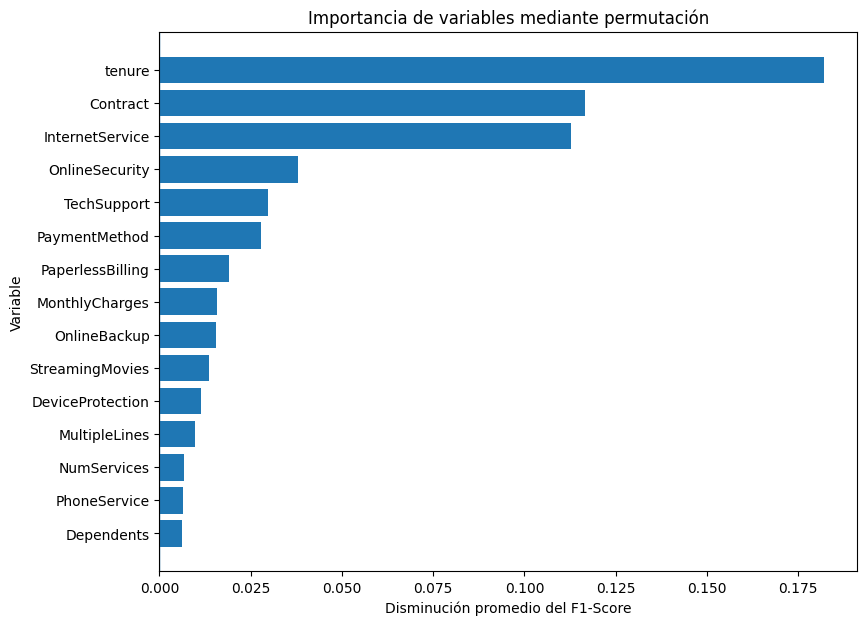

In [94]:
top_perm = importancia_permutacion.head(15).sort_values(
    'Importancia'
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_perm['Variable'],
    top_perm['Importancia']
)

plt.axvline(0, linewidth=1)
plt.title('Importancia de variables mediante permutación')
plt.xlabel('Disminución promedio del F1-Score')
plt.ylabel('Variable')
plt.show()

**Interpretación:**  
La importancia por permutación muestra que `tenure` es la variable que mayor contribución realiza al desempeño de la Regresión Logística, con una importancia promedio de 0,1820 sobre el F1-Score. Esto confirma que el tiempo de permanencia del cliente constituye uno de los principales factores para diferenciar entre clientes que permanecen y clientes que abandonan.

En segundo y tercer lugar se encuentran `Contract`, con una importancia de 0,1167, e `InternetService`, con 0,1126. Estos resultados son consistentes con el análisis exploratorio, donde los clientes con contratos mensuales presentaron una tasa de abandono del 42,71 %, mientras que los contratos de dos años registraron únicamente 2,83 %. Asimismo, los usuarios de fibra óptica mostraron una tasa de abandono del 41,89 %, superior a la observada en DSL y en clientes sin servicio de Internet.

Otras variables que aportan información al modelo son `OnlineSecurity`, `TechSupport`, `PaymentMethod`, `PaperlessBilling` y `MonthlyCharges`, aunque su influencia es menor.

La variable derivada `NumServices` presenta una importancia positiva pero reducida, indicando que la cantidad total de servicios contratados aporta información complementaria, aunque no constituye uno de los principales predictores del abandono.

Los valores de importancia deben interpretarse como contribuciones al desempeño predictivo del modelo y no como relaciones causales.

## 11. Extracción y almacenamiento del modelo seleccionado

Después de comparar los modelos mediante validación cruzada y evaluación sobre el conjunto de prueba, se seleccionó la Regresión Logística como modelo final debido a que presentó el mejor desempeño en Accuracy, Precision, Recall y F1-Score.

El modelo fue construido mediante un `Pipeline` que integra tanto el preprocesamiento de las variables como el algoritmo de clasificación. Por esta razón, al guardar el Pipeline se conserva conjuntamente la codificación de variables categóricas, el escalado de variables numéricas y el modelo entrenado.

Esta estructura permitirá utilizar posteriormente el mismo procedimiento sobre nuevos clientes mediante una API y una aplicación web.

In [95]:
import joblib

joblib.dump(
    modelo_logistico,
    'modelo_churn_regresion_logistica.pkl'
)

print("Modelo guardado correctamente.")

Modelo guardado correctamente.


In [96]:
import os

print(
    "Archivo creado:",
    os.path.exists('modelo_churn_regresion_logistica.pkl')
)

print(
    "Tamaño del archivo:",
    os.path.getsize('modelo_churn_regresion_logistica.pkl'),
    "bytes"
)

Archivo creado: True
Tamaño del archivo: 8033 bytes


### 11.1 Verificación del modelo almacenado

Para verificar que el modelo fue almacenado correctamente, se carga nuevamente el archivo generado y se realizan predicciones sobre el conjunto de prueba. Posteriormente, estas predicciones se comparan con las obtenidas antes de guardar el modelo.

In [97]:
modelo_cargado = joblib.load(
    'modelo_churn_regresion_logistica.pkl'
)

predicciones_cargado = modelo_cargado.predict(X_test)

print(
    "Predicciones iguales:",
    np.array_equal(pred_logistico, predicciones_cargado)
)

Predicciones iguales: True


In [98]:
print(
    "Accuracy del modelo cargado:",
    round(
        accuracy_score(y_test, predicciones_cargado),
        4
    )
)

Accuracy del modelo cargado: 0.8013


**Interpretación:**  
El modelo seleccionado fue almacenado correctamente en formato `.pkl`, incluyendo tanto las etapas de preprocesamiento como el algoritmo de Regresión Logística.

Al cargar nuevamente el archivo, las predicciones obtenidas fueron idénticas a las generadas por el modelo original (`Predicciones iguales: True`) y se conservó un Accuracy de 0,8013.

Esta verificación confirma que el modelo puede ser reutilizado sin necesidad de volver a entrenarlo, permitiendo posteriormente su integración en una API y una aplicación web para realizar predicciones sobre nuevos clientes.

## 12. Predicción sobre nuevos clientes

Para comprobar la utilidad práctica del modelo almacenado, se realiza una predicción utilizando los datos de un cliente hipotético que no forma parte del conjunto de entrenamiento ni del conjunto de prueba.

El propósito es simular el funcionamiento que posteriormente tendrá la API y la aplicación web, donde el usuario ingresará las características de un cliente y el sistema devolverá la probabilidad estimada de abandono y la clasificación correspondiente.

### 12.1 Construcción de un nuevo registro

Se construye un registro hipotético utilizando las mismas características originales empleadas durante el desarrollo del modelo. Las variables derivadas `TenureGroup` y `NumServices` serán calculadas automáticamente a partir de la información ingresada.

In [99]:
cliente_nuevo = {
    'gender': 'Male',
    'SeniorCitizen': 0,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 2,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 85.00,
    'TotalCharges': 170.00
}

cliente_nuevo = pd.DataFrame([cliente_nuevo])

cliente_nuevo

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,85.0,170.0


### 12.2 Generación de características derivadas

Para garantizar que los nuevos clientes tengan la misma estructura utilizada durante el entrenamiento, se calculan automáticamente las variables `NumServices` y `TenureGroup`.

De esta manera, el usuario final no tendrá que calcular manualmente estas características cuando el modelo sea implementado en la aplicación.

In [100]:
columnas_servicios = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

cliente_nuevo['NumServices'] = (
    cliente_nuevo[columnas_servicios]
    .eq('Yes')
    .sum(axis=1)
)

cliente_nuevo['NumServices'] += (
    cliente_nuevo['InternetService'] != 'No'
).astype(int)

In [101]:
def obtener_grupo_permanencia(tenure):
    if tenure <= 12:
        return 'Nuevo'
    elif tenure <= 48:
        return 'Intermedio'
    else:
        return 'Antiguo'

cliente_nuevo['TenureGroup'] = (
    cliente_nuevo['tenure']
    .apply(obtener_grupo_permanencia)
)

In [102]:
cliente_nuevo[
    ['tenure', 'TenureGroup', 'NumServices']
]

,tenure,TenureGroup,NumServices
0,2,Nuevo,4


In [103]:
cliente_nuevo = cliente_nuevo[X.columns]

print("Número de variables:", cliente_nuevo.shape[1])
cliente_nuevo

Número de variables: 21


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,NumServices,TenureGroup
0,Male,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,85.0,170.0,4,Nuevo


### 12.3 Predicción de abandono

El modelo almacenado se utiliza para determinar si el nuevo cliente presenta riesgo de abandonar el servicio. Además de la clasificación binaria, se obtiene la probabilidad estimada de abandono.

In [104]:
prediccion = modelo_cargado.predict(cliente_nuevo)[0]

probabilidad = modelo_cargado.predict_proba(
    cliente_nuevo
)[0, 1]

print("Predicción:", prediccion)
print(
    "Probabilidad de abandono:",
    round(probabilidad * 100, 2),
    "%"
)

Predicción: 1
Probabilidad de abandono: 82.54 %


In [105]:
if prediccion == 1:
    resultado = "Cliente con riesgo de abandono"
else:
    resultado = "Cliente con baja predicción de abandono"

print("Resultado:", resultado)

Resultado: Cliente con riesgo de abandono


**Interpretación:**  
El modelo fue probado con un cliente hipotético que no formó parte de los datos utilizados durante el entrenamiento. A partir de las características ingresadas, las variables derivadas fueron generadas correctamente, clasificando al cliente dentro del grupo de permanencia `Nuevo` y contabilizando 4 servicios contratados.

El registro final contiene las 21 variables predictoras requeridas por el modelo. La Regresión Logística estimó una probabilidad de abandono del 82,54 %, superando el umbral de clasificación del 50 %, por lo que el cliente fue clasificado como un caso con riesgo de abandono.

Este resultado demuestra que el modelo almacenado puede recibir información de nuevos clientes, aplicar automáticamente el preprocesamiento aprendido y generar una predicción junto con una probabilidad estimada. Esta funcionalidad servirá como base para su posterior implementación mediante una API y una aplicación web.

## 13. Desarrollo de una API para el modelo predictivo

Con el propósito de permitir el uso del modelo fuera del entorno de Google Colab, se desarrolla una API utilizando FastAPI.

La API recibirá las características originales de un cliente, generará automáticamente las variables derivadas `NumServices` y `TenureGroup`, organizará la información con la misma estructura utilizada durante el entrenamiento y utilizará el modelo almacenado para calcular la probabilidad de abandono.

Como respuesta, el servicio devolverá la clasificación obtenida, la probabilidad estimada de abandono y una descripción comprensible del resultado.

In [106]:
import os

os.makedirs('api_churn', exist_ok=True)

joblib.dump(
    modelo_logistico,
    'api_churn/modelo_churn_regresion_logistica.pkl'
)

print("Modelo preparado para la API.")

Modelo preparado para la API.


In [107]:
%%writefile api_churn/api.py

from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd
import joblib

# Crear aplicación
app = FastAPI(
    title="API de Predicción de Churn",
    description="Predicción del abandono de clientes de telecomunicaciones",
    version="1.0"
)

# Cargar modelo
modelo = joblib.load(
    "modelo_churn_regresion_logistica.pkl"
)


# Estructura de los datos de entrada
class Cliente(BaseModel):
    gender: str
    SeniorCitizen: int
    Partner: str
    Dependents: str
    tenure: int
    PhoneService: str
    MultipleLines: str
    InternetService: str
    OnlineSecurity: str
    OnlineBackup: str
    DeviceProtection: str
    TechSupport: str
    StreamingTV: str
    StreamingMovies: str
    Contract: str
    PaperlessBilling: str
    PaymentMethod: str
    MonthlyCharges: float
    TotalCharges: float


def calcular_num_servicios(df):

    columnas_servicios = [
        'PhoneService',
        'MultipleLines',
        'OnlineSecurity',
        'OnlineBackup',
        'DeviceProtection',
        'TechSupport',
        'StreamingTV',
        'StreamingMovies'
    ]

    df['NumServices'] = (
        df[columnas_servicios]
        .eq('Yes')
        .sum(axis=1)
    )

    df['NumServices'] += (
        df['InternetService'] != 'No'
    ).astype(int)

    return df


def calcular_tenure_group(tenure):

    if tenure <= 12:
        return 'Nuevo'

    elif tenure <= 48:
        return 'Intermedio'

    else:
        return 'Antiguo'


@app.get("/")
def inicio():

    return {
        "mensaje": "API de predicción de abandono de clientes activa"
    }


@app.post("/predecir")
def predecir(cliente: Cliente):

    # Convertir datos recibidos a DataFrame
    datos = pd.DataFrame([cliente.model_dump()])

    # Feature Engineering
    datos = calcular_num_servicios(datos)

    datos['TenureGroup'] = datos['tenure'].apply(
        calcular_tenure_group
    )

    # Orden utilizado durante entrenamiento
    columnas_modelo = [
        'gender',
        'SeniorCitizen',
        'Partner',
        'Dependents',
        'tenure',
        'PhoneService',
        'MultipleLines',
        'InternetService',
        'OnlineSecurity',
        'OnlineBackup',
        'DeviceProtection',
        'TechSupport',
        'StreamingTV',
        'StreamingMovies',
        'Contract',
        'PaperlessBilling',
        'PaymentMethod',
        'MonthlyCharges',
        'TotalCharges',
        'NumServices',
        'TenureGroup'
    ]

    datos = datos[columnas_modelo]

    # Predicción
    prediccion = int(
        modelo.predict(datos)[0]
    )

    probabilidad = float(
        modelo.predict_proba(datos)[0, 1]
    )

    if prediccion == 1:
        resultado = "Cliente con riesgo de abandono"
    else:
        resultado = "Cliente con baja predicción de abandono"

    return {
        "prediccion": prediccion,
        "probabilidad_abandono": round(
            probabilidad * 100,
            2
        ),
        "resultado": resultado,
        "grupo_permanencia": str(
            datos.iloc[0]['TenureGroup']
        ),
        "numero_servicios": int(
            datos.iloc[0]['NumServices']
        )
    }

Writing api_churn/api.py


### 13.1 Dependencias necesarias para la API

Se genera un archivo `requirements.txt` que contiene las librerías necesarias para ejecutar el servicio y cargar correctamente el modelo predictivo.

In [108]:
%%writefile api_churn/requirements.txt
fastapi
uvicorn
pandas
scikit-learn
joblib

Writing api_churn/requirements.txt


In [109]:
import os

print(
    "API:",
    os.path.exists('api_churn/api.py')
)

print(
    "Modelo:",
    os.path.exists(
        'api_churn/modelo_churn_regresion_logistica.pkl'
    )
)

print(
    "Requirements:",
    os.path.exists(
        'api_churn/requirements.txt'
    )
)

API: True
Modelo: True
Requirements: True


In [110]:
os.listdir('api_churn')

['modelo_churn_regresion_logistica.pkl', 'requirements.txt', 'api.py']

### 13.2 Prueba funcional de la API

Una vez creados el código fuente de la API, el modelo almacenado y el archivo de dependencias, se realiza una prueba funcional del servicio.

La prueba consiste en enviar los datos de un cliente mediante una solicitud al endpoint `/predecir` y verificar que la API genere correctamente las variables derivadas, procese la información mediante el modelo almacenado y devuelva la clasificación junto con la probabilidad estimada de abandono.

In [111]:
!pip -q install fastapi uvicorn httpx

In [112]:
%cd api_churn

/content/api_churn


In [113]:
!ls

api.py	modelo_churn_regresion_logistica.pkl  requirements.txt


In [114]:
from fastapi.testclient import TestClient
from api import app

cliente_api = TestClient(app)

respuesta_inicio = cliente_api.get("/")

print(respuesta_inicio.status_code)
print(respuesta_inicio.json())

200
{'mensaje': 'API de predicción de abandono de clientes activa'}


In [115]:
datos_cliente = {
    "gender": "Male",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 2,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 85.00,
    "TotalCharges": 170.00
}

respuesta = cliente_api.post(
    "/predecir",
    json=datos_cliente
)

print("Código de respuesta:", respuesta.status_code)
print("Respuesta de la API:")
print(respuesta.json())

Código de respuesta: 200
Respuesta de la API:
{'prediccion': 1, 'probabilidad_abandono': 82.54, 'resultado': 'Cliente con riesgo de abandono', 'grupo_permanencia': 'Nuevo', 'numero_servicios': 4}


**Interpretación:**  
La prueba funcional de la API se completó satisfactoriamente. El endpoint principal respondió con un código HTTP 200, confirmando que el servicio se encuentra operativo.

Posteriormente, se enviaron mediante el endpoint `/predecir` las características de un cliente hipotético. La API generó automáticamente las variables derivadas, clasificándolo como cliente `Nuevo` y contabilizando 4 servicios contratados.

El modelo estimó una probabilidad de abandono del 82,54 % y clasificó al cliente como un caso con riesgo de abandono. Este resultado coincide exactamente con la predicción obtenida previamente en el notebook, demostrando que el modelo almacenado fue correctamente integrado y puede ser utilizado mediante una interfaz externa.

## 14. Desarrollo de la aplicación web

Con el propósito de facilitar la utilización del modelo por parte de usuarios sin conocimientos de programación, se desarrolla una aplicación web mediante Streamlit.

La aplicación permitirá ingresar las características de un cliente mediante un formulario gráfico. Una vez completados los datos, la WebApp enviará la información a la API desarrollada previamente y mostrará la predicción, la probabilidad estimada de abandono, el grupo de permanencia y la cantidad de servicios contratados.

La arquitectura implementada permite separar la interfaz de usuario del modelo predictivo, utilizando la API como mecanismo de comunicación entre ambos componentes.

In [116]:
!pip -q install streamlit requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 29.8 MB/s eta 0:00:00


In [117]:
%%writefile webapp.py

import streamlit as st
import requests

st.set_page_config(
    page_title="Predicción de abandono de clientes",
    page_icon="📊",
    layout="centered"
)

st.title("📊 Predicción de abandono de clientes")

st.write(
    """
    Esta aplicación utiliza un modelo de minería de datos para
    estimar la probabilidad de que un cliente de telecomunicaciones
    abandone el servicio.
    """
)

st.subheader("Datos del cliente")

gender = st.selectbox(
    "Género",
    ["Male", "Female"]
)

SeniorCitizen = st.selectbox(
    "¿Es adulto mayor?",
    [0, 1],
    format_func=lambda x: "Sí" if x == 1 else "No"
)

Partner = st.selectbox(
    "¿Tiene pareja?",
    ["No", "Yes"]
)

Dependents = st.selectbox(
    "¿Tiene dependientes?",
    ["No", "Yes"]
)

tenure = st.number_input(
    "Meses de permanencia",
    min_value=0,
    max_value=100,
    value=12
)

PhoneService = st.selectbox(
    "Servicio telefónico",
    ["Yes", "No"]
)

MultipleLines = st.selectbox(
    "Múltiples líneas",
    ["No", "Yes", "No phone service"]
)

InternetService = st.selectbox(
    "Servicio de Internet",
    ["DSL", "Fiber optic", "No"]
)

OnlineSecurity = st.selectbox(
    "Seguridad en línea",
    ["No", "Yes", "No internet service"]
)

OnlineBackup = st.selectbox(
    "Respaldo en línea",
    ["No", "Yes", "No internet service"]
)

DeviceProtection = st.selectbox(
    "Protección de dispositivos",
    ["No", "Yes", "No internet service"]
)

TechSupport = st.selectbox(
    "Soporte técnico",
    ["No", "Yes", "No internet service"]
)

StreamingTV = st.selectbox(
    "Streaming de TV",
    ["No", "Yes", "No internet service"]
)

StreamingMovies = st.selectbox(
    "Streaming de películas",
    ["No", "Yes", "No internet service"]
)

Contract = st.selectbox(
    "Tipo de contrato",
    [
        "Month-to-month",
        "One year",
        "Two year"
    ]
)

PaperlessBilling = st.selectbox(
    "Facturación electrónica",
    ["Yes", "No"]
)

PaymentMethod = st.selectbox(
    "Método de pago",
    [
        "Electronic check",
        "Mailed check",
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ]
)

MonthlyCharges = st.number_input(
    "Cargo mensual",
    min_value=0.0,
    value=70.0,
    step=0.01
)

TotalCharges = st.number_input(
    "Cargo total",
    min_value=0.0,
    value=1000.0,
    step=0.01
)

if st.button("Realizar predicción"):

    datos = {
        "gender": gender,
        "SeniorCitizen": SeniorCitizen,
        "Partner": Partner,
        "Dependents": Dependents,
        "tenure": tenure,
        "PhoneService": PhoneService,
        "MultipleLines": MultipleLines,
        "InternetService": InternetService,
        "OnlineSecurity": OnlineSecurity,
        "OnlineBackup": OnlineBackup,
        "DeviceProtection": DeviceProtection,
        "TechSupport": TechSupport,
        "StreamingTV": StreamingTV,
        "StreamingMovies": StreamingMovies,
        "Contract": Contract,
        "PaperlessBilling": PaperlessBilling,
        "PaymentMethod": PaymentMethod,
        "MonthlyCharges": MonthlyCharges,
        "TotalCharges": TotalCharges
    }

    try:

        respuesta = requests.post(
            "http://127.0.0.1:8000/predecir",
            json=datos
        )

        if respuesta.status_code == 200:

            resultado = respuesta.json()

            st.subheader("Resultado de la predicción")

            st.metric(
                "Probabilidad de abandono",
                f"{resultado['probabilidad_abandono']} %"
            )

            if resultado["prediccion"] == 1:

                st.error(
                    "⚠️ Cliente con riesgo de abandono"
                )

            else:

                st.success(
                    "✅ Cliente con baja predicción de abandono"
                )

            st.write(
                "**Grupo de permanencia:**",
                resultado["grupo_permanencia"]
            )

            st.write(
                "**Número de servicios:**",
                resultado["numero_servicios"]
            )

        else:

            st.error(
                "La API no pudo procesar la solicitud."
            )

    except Exception as error:

        st.error(
            "No fue posible conectarse con la API."
        )

        st.write(error)

Writing webapp.py


In [118]:
%%writefile requirements.txt
fastapi
uvicorn
pandas
scikit-learn
joblib
streamlit
requests

Overwriting requirements.txt


In [119]:
import os

print("Archivos del proyecto:")

for archivo in os.listdir():
    print("-", archivo)

Archivos del proyecto:
- modelo_churn_regresion_logistica.pkl
- __pycache__
- requirements.txt
- api.py
- webapp.py


In [120]:
print("API:", os.path.exists("api.py"))
print("WebApp:", os.path.exists("webapp.py"))
print(
    "Modelo:",
    os.path.exists(
        "modelo_churn_regresion_logistica.pkl"
    )
)
print(
    "Requirements:",
    os.path.exists("requirements.txt")
)

API: True
WebApp: True
Modelo: True
Requirements: True


### 14.1 Ejecución y prueba funcional de la aplicación web

Para comprobar el funcionamiento integral del sistema, se ejecutan simultáneamente la API desarrollada con FastAPI y la aplicación web construida con Streamlit.

La WebApp permite ingresar las características de un cliente mediante un formulario. Estos datos son enviados a la API, que genera las variables derivadas, procesa la información con el modelo de Regresión Logística almacenado y devuelve la predicción y la probabilidad estimada de abandono.

Esta prueba permite verificar la integración completa entre la interfaz de usuario, la API y el modelo predictivo.

In [122]:
import subprocess
import time
import requests

proceso_api = subprocess.Popen(
    [
        "uvicorn",
        "api:app",
        "--host", "0.0.0.0",
        "--port", "8000"
    ],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(3)

respuesta_api = requests.get(
    "http://127.0.0.1:8000/"
)

print("Estado API:", respuesta_api.status_code)
print("Respuesta:", respuesta_api.json())

Estado API: 200
Respuesta: {'mensaje': 'API de predicción de abandono de clientes activa'}


In [123]:
proceso_web = subprocess.Popen(
    [
        "streamlit",
        "run",
        "webapp.py",
        "--server.port", "8501",
        "--server.address", "0.0.0.0",
        "--server.headless", "true"
    ],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(5)

respuesta_web = requests.get(
    "http://127.0.0.1:8501"
)

print(
    "Estado WebApp:",
    respuesta_web.status_code
)

Estado WebApp: 200


In [124]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

In [125]:
!./cloudflared tunnel --url http://127.0.0.1:8501

2026-10-04T08:49:11Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-10-04T08:49:11Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-10-04T08:49:16Z INF +--------------------------------------------------------------------------------------------+
2026-10-04T08:49:16Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-10-04T08:49:16Z INF |  https://valuation-accepted-sample-thriller.trycloudfl

**Interpretación:**  
La prueba integral de la aplicación web se realizó satisfactoriamente. Tanto la API como la WebApp respondieron con código HTTP 200, confirmando que ambos servicios se encontraban operativos.

Al ingresar mediante la interfaz gráfica las características del cliente utilizado previamente para las pruebas, la aplicación obtuvo una probabilidad de abandono del 82,54 %, clasificándolo como un cliente con riesgo de abandono. Además, identificó correctamente su grupo de permanencia como `Nuevo` y contabilizó 4 servicios contratados.

El resultado coincide con las predicciones obtenidas previamente en el notebook y mediante la API, demostrando la correcta integración entre la interfaz web, el servicio API, el preprocesamiento de datos y el modelo predictivo.

## 15. Organización del repositorio del proyecto

Para garantizar la reproducibilidad y facilitar el acceso a los diferentes componentes desarrollados, se organiza el proyecto en una estructura de directorios que contiene el conjunto de datos, el modelo entrenado, el código fuente de la API, la aplicación web, las dependencias y el cuaderno de trabajo.

Esta estructura será posteriormente publicada en un repositorio Git, permitiendo conservar y compartir los recursos utilizados durante el desarrollo del componente práctico-experimental.

In [126]:
%cd /content

/content


In [127]:
import os

carpeta_proyecto = "CPE-Mineria-Datos-Telco-Churn"

os.makedirs(f"{carpeta_proyecto}/data", exist_ok=True)
os.makedirs(f"{carpeta_proyecto}/model", exist_ok=True)
os.makedirs(f"{carpeta_proyecto}/api", exist_ok=True)
os.makedirs(f"{carpeta_proyecto}/webapp", exist_ok=True)

print("Estructura de carpetas creada correctamente.")

Estructura de carpetas creada correctamente.


In [128]:
import shutil

shutil.copy(
    "/content/api_churn/modelo_churn_regresion_logistica.pkl",
    f"/content/{carpeta_proyecto}/model/modelo_churn_regresion_logistica.pkl"
)

shutil.copy(
    "/content/api_churn/api.py",
    f"/content/{carpeta_proyecto}/api/api.py"
)

shutil.copy(
    "/content/api_churn/webapp.py",
    f"/content/{carpeta_proyecto}/webapp/webapp.py"
)

shutil.copy(
    "/content/api_churn/requirements.txt",
    f"/content/{carpeta_proyecto}/requirements.txt"
)

print("Archivos del modelo, API y WebApp copiados correctamente.")

Archivos del modelo, API y WebApp copiados correctamente.


In [129]:
import glob

archivos_csv = glob.glob("/content/*.csv")

print(archivos_csv)

['/content/WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [130]:
shutil.copy(
    "/content/WA_Fn-UseC_-Telco-Customer-Churn.csv",
    f"/content/{carpeta_proyecto}/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

print("Dataset copiado correctamente.")

Dataset copiado correctamente.


In [131]:
for raiz, carpetas, archivos in os.walk(
    f"/content/{carpeta_proyecto}"
):
    nivel = raiz.replace(
        f"/content/{carpeta_proyecto}",
        ""
    ).count(os.sep)

    sangria = "    " * nivel
    print(f"{sangria}{os.path.basename(raiz)}/")

    for archivo in archivos:
        print(f"{sangria}    {archivo}")

CPE-Mineria-Datos-Telco-Churn/
    requirements.txt
    api/
        api.py
    model/
        modelo_churn_regresion_logistica.pkl
    webapp/
        webapp.py
    data/
        WA_Fn-UseC_-Telco-Customer-Churn.csv


**Interpretación:**  
La estructura del proyecto fue organizada en carpetas independientes para los datos, el modelo, la API y la aplicación web. Además, se mantiene un archivo de dependencias que permitirá reproducir el entorno necesario para ejecutar el sistema.

Esta organización facilita la identificación de cada componente desarrollado y permitirá posteriormente publicar el proyecto completo en un repositorio Git junto con el cuaderno `.ipynb` y los demás recursos requeridos para la entrega final.

### 15.1 Creación del archivo README del proyecto

Se crea un archivo `README.md` con el propósito de documentar de manera resumida el contenido del repositorio, el objetivo del proyecto, las técnicas utilizadas, los principales resultados obtenidos y la estructura de archivos.

Este documento permitirá que cualquier persona que acceda al repositorio pueda comprender rápidamente el propósito del proyecto y la función de cada uno de sus componentes.

In [132]:
%%writefile /content/CPE-Mineria-Datos-Telco-Churn/README.md

# Predicción del abandono de clientes mediante minería de datos

## Descripción

Este proyecto corresponde al Componente Práctico Experimental de la asignatura Minería de Datos.

El objetivo consiste en aplicar técnicas de minería de datos para desarrollar un modelo predictivo capaz de identificar clientes con riesgo de abandonar los servicios de una empresa de telecomunicaciones.

## Dataset

Se utilizó el conjunto de datos **Telco Customer Churn**, compuesto por:

- 7.043 registros
- 21 variables originales
- Variable objetivo: `Churn`

Durante el procesamiento se generaron además las variables derivadas:

- `NumServices`
- `TenureGroup`

## Proceso realizado

El proyecto incluye:

- Comprensión y exploración de datos.
- Análisis estadístico descriptivo.
- Identificación de valores faltantes.
- Verificación de registros duplicados.
- Análisis de valores atípicos mediante IQR.
- Preprocesamiento y transformación de datos.
- Feature Engineering.
- Codificación de variables categóricas.
- Escalado de variables numéricas.
- División de datos en entrenamiento y prueba.
- Entrenamiento de Regresión Logística.
- Entrenamiento de Random Forest.
- Validación cruzada con 5 particiones.
- Evaluación mediante Accuracy, Precision, Recall y F1-Score.
- Curva ROC y AUC.
- Interpretación de variables.
- Almacenamiento del modelo.
- Desarrollo de API con FastAPI.
- Desarrollo de WebApp con Streamlit.

## Modelos evaluados

### Regresión Logística

- Accuracy: 0.8013
- Precision: 0.6567
- Recall: 0.5267
- F1-Score: 0.5846
- AUC: 0.8413

### Random Forest

- Accuracy: 0.7786
- Precision: 0.6062
- Recall: 0.4733
- F1-Score: 0.5315

La Regresión Logística fue seleccionada como modelo final debido a que presentó mejores resultados en las métricas evaluadas.

## Variables relevantes

El análisis de importancia por permutación identificó como principales variables predictoras:

1. `tenure`
2. `Contract`
3. `InternetService`

## Despliegue

El modelo fue integrado mediante:

- API desarrollada con FastAPI.
- Aplicación web desarrollada con Streamlit.

La aplicación permite ingresar los datos de un cliente y obtener:

- Predicción de abandono.
- Probabilidad estimada.
- Grupo de permanencia.
- Número de servicios contratados.

## Estructura del proyecto

CPE-Mineria-Datos-Telco-Churn/

- `data/`
  - Dataset utilizado.
- `model/`
  - Modelo entrenado.
- `api/`
  - Código fuente de la API.
- `webapp/`
  - Código fuente de la aplicación web.
- `requirements.txt`
  - Dependencias del proyecto.
- `README.md`
  - Documentación general.
- `CPE_Mineria_Datos_Telco_Churn.ipynb`
  - Cuaderno completo del análisis.

## Tecnologías utilizadas

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- FastAPI
- Streamlit
- Joblib
- Google Colab

## Autor

Proyecto académico desarrollado para la asignatura Minería de Datos.

Writing /content/CPE-Mineria-Datos-Telco-Churn/README.md


In [133]:
import os

print(
    "README:",
    os.path.exists(
        "/content/CPE-Mineria-Datos-Telco-Churn/README.md"
    )
)

README: True


In [134]:
for raiz, carpetas, archivos in os.walk(
    "/content/CPE-Mineria-Datos-Telco-Churn"
):
    nivel = raiz.replace(
        "/content/CPE-Mineria-Datos-Telco-Churn",
        ""
    ).count(os.sep)

    sangria = "    " * nivel
    print(f"{sangria}{os.path.basename(raiz)}/")

    for archivo in archivos:
        print(f"{sangria}    {archivo}")

CPE-Mineria-Datos-Telco-Churn/
    README.md
    requirements.txt
    api/
        api.py
    model/
        modelo_churn_regresion_logistica.pkl
    webapp/
        webapp.py
    data/
        WA_Fn-UseC_-Telco-Customer-Churn.csv


### 15.2 Preparación de los archivos para publicación en GitHub

Una vez organizada la estructura del proyecto y creado el archivo README, se preparan los archivos para su publicación en un repositorio de GitHub.

El repositorio permitirá almacenar y compartir el conjunto de datos, el modelo entrenado, el código fuente de la API, la aplicación web, las dependencias y el cuaderno completo del análisis realizado.

In [135]:
import shutil

shutil.make_archive(
    "/content/CPE-Mineria-Datos-Telco-Churn",
    "zip",
    "/content/CPE-Mineria-Datos-Telco-Churn"
)

print("Proyecto comprimido correctamente.")

Proyecto comprimido correctamente.


In [136]:
import os

print(
    "ZIP creado:",
    os.path.exists(
        "/content/CPE-Mineria-Datos-Telco-Churn.zip"
    )
)

ZIP creado: True


In [137]:
from google.colab import files

files.download(
    "/content/CPE-Mineria-Datos-Telco-Churn.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Interpretación:**  
El proyecto fue organizado y publicado correctamente en un repositorio de GitHub. El repositorio contiene el conjunto de datos utilizado, el modelo predictivo almacenado, el código fuente de la API, la aplicación web, el archivo de dependencias, la documentación README y el cuaderno completo del análisis en formato `.ipynb`.

La publicación de estos recursos permite conservar la estructura del proyecto, facilitar su reproducción y proporcionar acceso al código y a los componentes desarrollados durante el CPE.

## 16. Aplicación del modelo DIKW

El modelo DIKW permite representar la transformación progresiva de los datos en conocimiento útil para apoyar la toma de decisiones. En este proyecto, el proceso parte de los registros originales de clientes de telecomunicaciones y avanza mediante el análisis exploratorio, el procesamiento de los datos, la construcción de modelos predictivos y la interpretación de sus resultados.

Las cuatro etapas consideradas son: Datos (Data), Información (Information), Conocimiento (Knowledge) y Sabiduría (Wisdom).

### 16.1 Datos (Data)

La primera etapa corresponde a los datos originales obtenidos del conjunto **Telco Customer Churn**. El dataset contiene 7.043 registros y 21 variables relacionadas con características demográficas, servicios contratados, permanencia, tipo de contrato, método de pago, cargos y abandono del cliente.

La variable objetivo utilizada fue `Churn`, donde el 73,46 % de los clientes permanecieron en el servicio y el 26,54 % abandonaron.

Durante la revisión de calidad se identificaron 11 registros con valores vacíos en `TotalCharges`, equivalentes aproximadamente al 0,16 % del conjunto de datos. Estos registros correspondían a clientes con `tenure = 0`, por lo que el valor de `TotalCharges` fue transformado a formato numérico e imputado con 0.

No se encontraron registros duplicados ni valores atípicos mediante el criterio del rango intercuartílico (IQR) en las variables numéricas analizadas.

Esta etapa representa los datos en su forma inicial, antes de generar patrones, relaciones o conocimiento predictivo.

### 16.2 Información (Information)

En la segunda etapa, los datos fueron organizados, resumidos y analizados mediante técnicas de análisis exploratorio y visualización. Esto permitió transformar los registros individuales en información comprensible sobre el comportamiento de los clientes.

Entre los principales hallazgos se identificó que los clientes clasificados como `Nuevo` presentaron una tasa de abandono del 47,44 %, mientras que los clientes `Intermedio` alcanzaron el 23,64 % y los clientes `Antiguo` únicamente el 9,51 %.

El tipo de contrato también mostró diferencias importantes. Los clientes con contrato `Month-to-month` registraron una tasa de abandono del 42,71 %, mientras que aquellos con contrato de un año presentaron 11,27 % y los de dos años solamente 2,83 %.

En relación con el servicio de Internet, los clientes con `Fiber optic` presentaron una tasa de abandono del 41,89 %, superior al 18,96 % observado en usuarios con DSL y al 7,40 % de los clientes sin servicio de Internet.

Además, los clientes que abandonaron el servicio presentaron un cargo mensual promedio de 74,44, mientras que aquellos que permanecieron registraron un promedio de 61,27.

Estos resultados permitieron identificar patrones y relaciones relevantes entre las características de los clientes y la variable objetivo `Churn`, convirtiendo los datos originales en información útil para la construcción posterior de modelos predictivos.

### 16.3 Conocimiento (Knowledge)

En la tercera etapa, la información obtenida mediante el análisis exploratorio fue utilizada para construir y evaluar modelos de clasificación capaces de predecir el abandono de clientes.

Se implementaron dos algoritmos: Regresión Logística y Random Forest. Para garantizar una evaluación más robusta, ambos modelos fueron analizados mediante validación cruzada estratificada de 5 particiones.

Durante la validación cruzada, la Regresión Logística obtuvo una precisión promedio de 0,8080 y un F1-Score promedio de 0,5977. Por su parte, Random Forest alcanzó una precisión promedio de 0,7883 y un F1-Score promedio de 0,5450.

Posteriormente, los modelos fueron evaluados sobre el conjunto de prueba. La Regresión Logística alcanzó un Accuracy de 0,8013, Precision de 0,6567, Recall de 0,5267 y F1-Score de 0,5846. Además, obtuvo un valor AUC de 0,8413, mostrando una buena capacidad para diferenciar entre clientes que abandonan y clientes que permanecen.

Random Forest obtuvo un Accuracy de 0,7786, Precision de 0,6062, Recall de 0,4733 y F1-Score de 0,5315.

A partir de esta comparación, la Regresión Logística fue seleccionada como modelo final, debido a que presentó un mejor desempeño tanto en la validación cruzada como en el conjunto de prueba.

El análisis de importancia por permutación mostró que las variables con mayor influencia predictiva fueron `tenure`, `Contract` e `InternetService`. Estos resultados permiten transformar la información obtenida previamente en conocimiento útil sobre los factores asociados al riesgo de abandono.

Finalmente, el modelo seleccionado fue almacenado en formato `.pkl` e integrado en una API y una aplicación web, permitiendo realizar predicciones sobre nuevos clientes de manera automática.

### 16.4 Sabiduría (Wisdom)

En la etapa final del modelo DIKW, el conocimiento generado se utiliza como apoyo para la toma de decisiones orientadas a la retención de clientes.

Los resultados obtenidos permiten identificar perfiles con mayor riesgo de abandono, especialmente clientes con menor tiempo de permanencia, contratos mensuales y determinados tipos de servicio de Internet. Esta información puede ser utilizada para priorizar acciones de seguimiento, campañas de fidelización, ofertas personalizadas o revisión de condiciones comerciales dirigidas a los grupos con mayor probabilidad estimada de abandono.

El modelo seleccionado no debe considerarse como una herramienta de decisión absoluta, sino como un mecanismo de apoyo. En el conjunto de prueba, la Regresión Logística identificó correctamente 197 clientes que abandonaron el servicio, pero también dejó sin detectar 177 casos de abandono. Por esta razón, las predicciones deben complementarse con criterios comerciales y análisis adicionales.

La implementación mediante API y WebApp permite transformar los resultados del modelo en una herramienta práctica, donde el usuario puede ingresar las características de un cliente y obtener una probabilidad estimada de abandono de forma automática.

De esta manera, el proceso completo permite pasar de datos originales a información descriptiva, posteriormente a conocimiento predictivo y finalmente a una aplicación orientada al apoyo de decisiones empresariales. Además, se recomienda realizar evaluaciones periódicas del desempeño del modelo y actualizarlo cuando se disponga de nuevos datos, con el fin de mantener su utilidad predictiva.

## 17. Conclusiones

El desarrollo de este proyecto permitió comprobar que la minería de datos puede ser utilizada como una herramienta útil para analizar el comportamiento de los clientes y estimar posibles casos de abandono en una empresa de telecomunicaciones. A partir del análisis exploratorio se identificaron patrones relevantes, especialmente en clientes con menor tiempo de permanencia, contratos mensuales y servicio de Internet por fibra óptica, grupos que presentaron mayores porcentajes de abandono dentro del conjunto de datos.

La etapa de preparación de los datos fue fundamental para obtener resultados confiables. Durante este proceso se revisaron valores faltantes, registros duplicados y posibles valores atípicos. También se transformaron variables y se generaron nuevas características, como `NumServices` y `TenureGroup`, que permitieron representar de mejor manera la información disponible antes del entrenamiento de los modelos.

En la fase de modelado se compararon dos técnicas de clasificación: Regresión Logística y Random Forest. Los resultados obtenidos tanto en la validación cruzada como en el conjunto de prueba mostraron un mejor comportamiento de la Regresión Logística. Este modelo alcanzó un Accuracy de 0,8013 y un AUC de 0,8413, además de superar al Random Forest en Precision, Recall y F1-Score. Por esta razón, fue seleccionado como el modelo principal del proyecto.

La interpretación de los resultados permitió observar que variables como el tiempo de permanencia del cliente, el tipo de contrato y el servicio de Internet aportan información importante para la predicción del abandono. Estos resultados pueden ser de utilidad para identificar clientes que requieren mayor atención y para orientar futuras estrategias de fidelización. Sin embargo, las relaciones encontradas deben considerarse como asociaciones predictivas y no como causas directas del abandono.

Finalmente, la implementación del modelo mediante una API y una aplicación web permitió llevar el análisis más allá del entorno de desarrollo. Las pruebas realizadas demostraron que el modelo puede recibir información de nuevos clientes y generar una estimación automática del riesgo de abandono. A pesar de los resultados obtenidos, el modelo no identifica todos los casos correctamente, por lo que su uso debe entenderse como un apoyo para la toma de decisiones y no como un criterio único. También sería conveniente actualizar y evaluar nuevamente el modelo cuando se disponga de nuevos datos.